# ECG and PCG signal exploration across measured LVEF

This notebook supports visual, hypothesis-generating review of the four acquisition sites. It organizes patients by **measured LVEF**; it does not use model predictions. In this project, HFrEF is defined as LVEF $\leq 40\%$.

The labels *lowest LVEF*, *highest LVEF*, and *non-HFrEF* describe only this dataset variable. They do not establish overall health, diagnosis severity, or which features the model uses.

## Setup and configuration

The settings below control group size, random sampling, gallery pages, and the default signal window. The notebook works when launched from the project root or from `notebooks/`. Signals are loaded only when validation or a plot requests them.

In [1]:
from datetime import datetime
from functools import lru_cache
from pathlib import Path
import sys
import warnings

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal as scipy_signal
import seaborn as sns
import soundfile as sf
import torch
from IPython.display import clear_output, display

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'src').is_dir() and (PROJECT_DIR.parent / 'src').is_dir():
    PROJECT_DIR = PROJECT_DIR.parent
if not (PROJECT_DIR / 'src').is_dir():
    raise FileNotFoundError('Run this notebook from the CardioFusion root or notebooks directory.')
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

warnings.filterwarnings('ignore', message='IProgress not found.*')
from src.preprocessing import (
    CHANNEL_ORDER, CHANNEL_ORDER_STRING, DURATION_SECONDS,
    ECG_FS, ECG_SAMPLES, PCG_FS, PCG_SAMPLES, butter_bandpass_filter,
)
from src.signal_analysis import (
    beat_morphology_features, detect_ecg_beats, extract_aligned_beats,
    pcg_envelope, summarize_ecg, summarize_processed_ecg,
)

GROUP_N = 10
RANDOM_SEED = 42
DEFAULT_SCOPE = 'development'  # options: development, test, or all
DEFAULT_SITE = 'APEX'
DEFAULT_START_S = 0.0
DEFAULT_DURATION_S = 5.0
GALLERY_PAGE_SIZE = 4
VALIDATE_ALL_SIGNAL_SHAPES = False
REVIEW_WINDOWS = (0.0, 10.0, 20.0)
BLIND_N_PER_CLASS = 10
BEAT_PRE_SECONDS = 0.20
BEAT_POST_SECONDS = 0.28
DETECTOR_SETTINGS = {
    'min_hr_bpm': 30, 'max_hr_bpm': 200,
    'prominence_scale': 1.25, 'minimum_prominence': 1.5,
    'minimum_beats': 3, 'minimum_plausible_fraction': 0.75,
}
ANALYSIS_OUTPUT_DIR = PROJECT_DIR / 'analysis_outputs'
sns.set_theme(style='whitegrid', context='notebook')

In [2]:
PROCESSED_ROOT = PROJECT_DIR / 'data' / 'processed' / 'patient_4ch'
RAW_ROOT = PROJECT_DIR / 'data' / 'raw'
EXPECTED = {'ECG': (ECG_FS, ECG_SAMPLES), 'PCG': (PCG_FS, PCG_SAMPLES)}

def raw_signal_path(row, modality, site):
    suffix = f'{row.Patient_ID}_{site}_{modality}.wav'
    if row.Split == 'development':
        return RAW_ROOT / 'HFrEF_5_folds' / f'fold_{int(row.Fold)}' / suffix
    return RAW_ROOT / 'HFrEF_community_scenario_test_set' / 'test_set' / suffix

frames = []
for split in ('development', 'test'):
    data_dir = PROCESSED_ROOT / split
    metadata_path = data_dir / 'processed_metadata.csv'
    if not metadata_path.is_file():
        raise FileNotFoundError(f'Missing metadata: {metadata_path}')
    frame = pd.read_csv(metadata_path, dtype={'Patient_ID': str})
    frame.insert(0, 'Split', split)
    frame['ECG_Path'] = frame['ECG_File'].map(lambda value: str(data_dir / value))
    frame['PCG_Path'] = frame['PCG_File'].map(lambda value: str(data_dir / value))
    frames.append(frame)

patient_index = pd.concat(frames, ignore_index=True)
patient_index['LVEF'] = pd.to_numeric(patient_index['LVEF'], errors='raise')
patient_index = patient_index.sort_values(['LVEF', 'Patient_ID'], kind='stable').reset_index(drop=True)
patient_index['LVEF_percent'] = 100 * patient_index['LVEF']
patient_index['Class'] = patient_index['Label'].map({0: 'non-HFrEF', 1: 'HFrEF'})
patient_index['Raw_available'] = patient_index.apply(
    lambda row: all(raw_signal_path(row, modality, site).is_file()
                    for modality in EXPECTED for site in CHANNEL_ORDER), axis=1
)

dev_ids = set(patient_index.loc[patient_index.Split == 'development', 'Patient_ID'])
test_ids = set(patient_index.loc[patient_index.Split == 'test', 'Patient_ID'])

def scoped_index(scope='development'):
    if scope not in {'development', 'test', 'all'}:
        raise ValueError("scope must be 'development', 'test', or 'all'")
    return patient_index if scope == 'all' else patient_index[patient_index.Split == scope]

print(f'Indexed {len(patient_index)} patients ({len(dev_ids)} development, {len(test_ids)} test).')

Indexed 620 patients (500 development, 120 test).


## Signal loading and plotting functions

These helpers load only the selected signal. Processed signals are filtered and standardized independently per site: ECG is 0.5–40 Hz at 500 Hz; PCG is 25–400 Hz at 4000 Hz. Processed amplitudes are z-scores, so original amplitude scale is absent. Raw WAV and filtered, non-standardized views use digital WAV amplitude because no physical calibration is documented.

The four channels are acquisition **sites** (APEX, LLSB, LUSB, RUSB), not standard ECG leads. Repository preprocessing documentation states that site order does not imply temporal alignment. Cross-modality synchronization is not assumed, so paired plots are visual comparisons rather than timing analyses.

In [3]:
def patient_row(patient_id, split=None):
    matches = patient_index[patient_index.Patient_ID.eq(str(patient_id))]
    if split is not None:
        matches = matches[matches.Split.eq(split)]
    if len(matches) != 1:
        raise KeyError(f'Expected one patient for ID={patient_id!r}, split={split!r}; found {len(matches)}.')
    return matches.iloc[0]

@lru_cache(maxsize=24)
def _load_processed(path):
    return torch.load(Path(path), map_location='cpu', weights_only=True).numpy()

@lru_cache(maxsize=48)
def _load_raw(path):
    values, sample_rate = sf.read(Path(path), dtype='float32')
    if values.ndim != 1 or not np.isfinite(values).all():
        raise ValueError(f'Expected one finite mono signal: {path}')
    return values, sample_rate

def load_signal(patient_id, modality='ECG', site='APEX', representation='processed', split=None):
    modality = modality.upper()
    if modality not in EXPECTED or site not in CHANNEL_ORDER:
        raise ValueError(f'Use modality ECG/PCG and site in {CHANNEL_ORDER}.')
    if representation not in {'processed', 'raw', 'filtered'}:
        raise ValueError("representation must be 'processed', 'raw', or 'filtered'")
    row = patient_row(patient_id, split)
    fs, samples = EXPECTED[modality]
    if representation == 'processed':
        values = _load_processed(str(row[f'{modality}_Path']))[CHANNEL_ORDER.index(site)]
        return values, fs, 'z-score'
    path = raw_signal_path(row, modality, site)
    if not path.is_file():
        raise FileNotFoundError(f'Raw signal unavailable: {path}')
    values, actual_fs = _load_raw(str(path))
    if actual_fs != fs or len(values) != samples:
        raise ValueError(f'{path}: expected {samples} samples at {fs} Hz; got {len(values)} at {actual_fs}.')
    if representation == 'filtered':
        low, high = (0.5, 40.0) if modality == 'ECG' else (25.0, 400.0)
        values = butter_bandpass_filter(values, low, high, fs)
    return np.asarray(values), fs, 'digital amplitude (WAV units)'

def peak_preserving_trace(values, fs, max_bins=1500):
    values = np.asarray(values)
    if len(values) <= max_bins:
        return np.arange(len(values)) / fs, values
    edges = np.linspace(0, len(values), max_bins + 1, dtype=int)
    times, amplitudes = [], []
    for left, right in zip(edges[:-1], edges[1:]):
        segment = values[left:right]
        if not len(segment):
            continue
        for offset in np.sort([int(np.argmin(segment)), int(np.argmax(segment))]):
            times.append((left + offset) / fs)
            amplitudes.append(segment[offset])
    return np.asarray(times), np.asarray(amplitudes)

def _plot_modality(ax_overview, ax_excerpt, row, modality, site, start_s, duration_s, representation):
    values, fs, unit = load_signal(row.Patient_ID, modality, site, representation, row.Split)
    if start_s < 0 or duration_s <= 0 or start_s + duration_s > DURATION_SECONDS:
        raise ValueError(f'Window must lie within 0–{DURATION_SECONDS} seconds.')
    overview_t, overview_y = peak_preserving_trace(values, fs)
    ax_overview.plot(overview_t, overview_y, color='#335c81', linewidth=0.6)
    ax_overview.axvspan(start_s, start_s + duration_s, color='#e59f3a', alpha=0.22)
    ax_overview.set(xlabel='Time (s)', ylabel=unit, xlim=(0, DURATION_SECONDS), title=f'{modality} — full 30 s overview')
    left, right = int(round(start_s * fs)), int(round((start_s + duration_s) * fs))
    excerpt = values[left:right]
    excerpt_t = np.arange(left, right) / fs
    ax_excerpt.plot(excerpt_t, excerpt, color='#9e3d3d', linewidth=0.8)
    ax_excerpt.set(xlabel='Time (s)', ylabel=unit, xlim=(start_s, start_s + duration_s),
                   title=f'{modality} — {start_s:g}–{start_s + duration_s:g} s excerpt')

def plot_patient(patient_id, modality='ECG', site=DEFAULT_SITE, start_s=DEFAULT_START_S,
                 duration_s=DEFAULT_DURATION_S, representation='processed', split=None):
    row = patient_row(patient_id, split)
    modalities = ('ECG', 'PCG') if modality.lower() == 'paired' else (modality.upper(),)
    fig, axes = plt.subplots(len(modalities), 2, figsize=(14, 3.8 * len(modalities)), squeeze=False, constrained_layout=True)
    for index, current_modality in enumerate(modalities):
        _plot_modality(axes[index, 0], axes[index, 1], row, current_modality, site, start_s, duration_s, representation)
    fold = 'test' if row.Fold == -1 else int(row.Fold)
    fig.suptitle(f'Patient {row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {row.Class} | {row.Split}, fold {fold} | site {site} | {representation}', fontsize=13)
    plt.show()
    return fig

## Patient signal browser

This is the notebook's main workspace. Choose the split scope and patient first, then the modality, site, representation, and time window. No signal is loaded until **Load patient** is clicked.

In [4]:
def patient_options_for_scope(scope):
    eligible = scoped_index(scope)
    return [(f'{row.Patient_ID} — LVEF {row.LVEF_percent:.1f}% ({row.Class})', row.Patient_ID)
            for row in eligible.itertuples(index=False)]

scope_control = widgets.Dropdown(
    options=['development', 'test', 'all'], value=DEFAULT_SCOPE, description='Scope')
patient_control = widgets.Dropdown(
    options=patient_options_for_scope(DEFAULT_SCOPE), description='Patient',
    layout=widgets.Layout(width='520px'))
modality_control = widgets.Dropdown(
    options=['ECG', 'PCG', 'paired'], value='ECG', description='Modality')
site_control = widgets.Dropdown(
    options=list(CHANNEL_ORDER), value=DEFAULT_SITE, description='Site')
representation_control = widgets.Dropdown(
    options=['processed', 'raw', 'filtered'], value='processed', description='View')
start_control = widgets.FloatSlider(
    min=0, max=DURATION_SECONDS-DEFAULT_DURATION_S, step=0.5, value=0,
    description='Start (s)', continuous_update=False)
duration_control = widgets.FloatSlider(
    min=1, max=10, step=1, value=DEFAULT_DURATION_S,
    description='Duration', continuous_update=False)
load_button = widgets.Button(description='Load patient', button_style='primary', icon='line-chart')
browser_status = widgets.HTML(value='<i>Choose settings, then click Load patient.</i>')
browser_output = widgets.Output()

def update_patient_options(change):
    patient_control.options = patient_options_for_scope(change['new'])
    browser_status.value = '<i>Scope changed. Click Load patient when ready.</i>'

def keep_window_valid(change):
    start_control.max = DURATION_SECONDS - change['new']
    if start_control.value > start_control.max:
        start_control.value = start_control.max

def load_selected_patient(_button):
    browser_status.value = '<i>Loading signal and drawing plot…</i>'
    with browser_output:
        clear_output(wait=True)
        plot_patient(
            patient_control.value, modality_control.value, site_control.value,
            start_control.value, duration_control.value, representation_control.value)
    browser_status.value = '<i>Plot ready.</i>'

scope_control.observe(update_patient_options, names='value')
duration_control.observe(keep_window_valid, names='value')
load_button.on_click(load_selected_patient)
controls = widgets.VBox([
    widgets.HBox([scope_control, patient_control]),
    widgets.HBox([modality_control, site_control, representation_control]),
    widgets.HBox([start_control, duration_control]),
    widgets.HBox([load_button, browser_status]),
])
display(controls, browser_output)

Output()

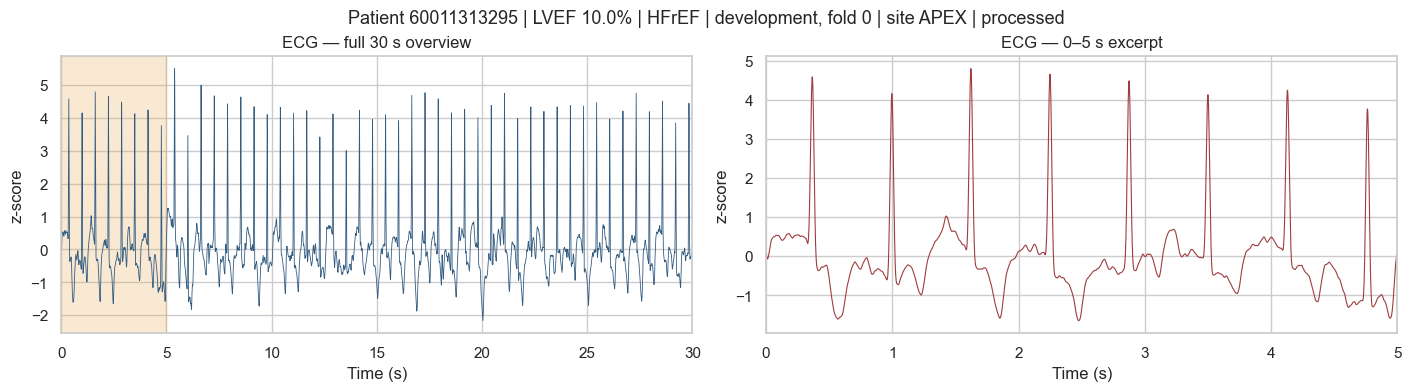

In [5]:
# Parameter-cell alternative: edit these values and rerun this cell.
VIEW_PATIENT_ID = scoped_index(DEFAULT_SCOPE).iloc[0].Patient_ID
VIEW_MODALITY = 'ECG'  # ECG, PCG, or paired
VIEW_SITE = DEFAULT_SITE
VIEW_REPRESENTATION = 'processed'  # processed, raw, or filtered
VIEW_START_S = DEFAULT_START_S
VIEW_DURATION_S = DEFAULT_DURATION_S
_ = plot_patient(VIEW_PATIENT_ID, VIEW_MODALITY, VIEW_SITE, VIEW_START_S,
                 VIEW_DURATION_S, VIEW_REPRESENTATION)

## Main observations

**The ECG results are promising, but we should check their reliability before adding augmentation.** Snapshot of the development analysis reviewed on 11 September 2026; these notes do not update automatically.

- **No clear visual rule separates the groups.** Among 500 development patients (60 HFrEF, 440 non-HFrEF), HFrEF patients had faster estimated heart rates (median 83 versus 74 bpm), lower standardized median-beat peak-to-peak values (5.57 versus 6.35), and lower measured beat variability. The groups overlap substantially.
- **The cause is uncertain.** Heart rate, normalization, recording quality, and site may explain some differences. Standardized beat height is not physical voltage.
- **The saved ECG model ranks patients well on one validation fold:** AUROC 0.956 and AUPRC 0.769. That fold has only 12 HFrEF patients; performance across the other folds remains unverified.
- **Automatic beat checks are not physiological validation.** 1,997 of 2,000 recordings passed the detector checks; incorrect peaks can still pass. PCG plots show repeatability in one example, not a class-specific finding.

**Suggested next step:** audit the unchanged ECG baseline across the five development folds and compare it with simple heart-rate/recording-quality predictors. Keep test data out of these decisions. Detailed caveats and proposed experiments are retained in the draft notes near the end.

## Blinded visual review

This optional review aid shuffles a balanced development-only subset before any waveform is inspected. The initial interface shows only an anonymous review ID. Reveal the patient and label only after recording an observation. This reduces expectation bias, but it is not formal blinding because the analyst can still access the labeled data elsewhere in the notebook.

Changing controls does not load a signal. Use **Load anonymous recording**, enter only observations you actually made, then use **Save observation**. Export creates a new timestamped file and never overwrites an earlier notes file.

In [6]:
def make_blind_review_set(n_per_class=BLIND_N_PER_CLASS, seed=RANDOM_SEED):
    development = scoped_index('development')
    selected = []
    for label in (0, 1):
        group = development[development.Label.eq(label)]
        selected.append(group.sample(n=min(n_per_class, len(group)), random_state=seed + label))
    shuffled = pd.concat(selected).sample(frac=1, random_state=seed).reset_index(drop=True)
    shuffled.insert(0, 'Review_ID', [f'REVIEW-{i:03d}' for i in range(1, len(shuffled) + 1)])
    return shuffled

blind_mapping = make_blind_review_set()
blind_observations = pd.DataFrame(columns=[
    'Review_ID', 'Site', 'Start_s', 'Duration_s', 'Beat_regularity',
    'Repeating_shape', 'Beat_consistency', 'Baseline_movement',
    'Noise_clipping_dropouts', 'General_notes',
])

def plot_anonymous_recording(review_id, site='APEX', start_s=0.0, duration_s=5.0):
    row = blind_mapping.loc[blind_mapping.Review_ID.eq(review_id)].iloc[0]
    values, fs, unit = load_signal(row.Patient_ID, 'ECG', site, 'processed', 'development')
    if start_s < 0 or duration_s <= 0 or start_s + duration_s > DURATION_SECONDS:
        raise ValueError(f'Window must lie within 0–{DURATION_SECONDS} seconds.')
    left, right = int(round(start_s * fs)), int(round((start_s + duration_s) * fs))
    fig, ax = plt.subplots(figsize=(13, 3.5), constrained_layout=True)
    ax.plot(np.arange(left, right) / fs, values[left:right], linewidth=0.8)
    ax.set(xlabel='Time (s)', ylabel=unit, xlim=(start_s, start_s + duration_s),
           title=f'{review_id} | ECG | site {site} | processed')
    plt.show()

blind_review_control = widgets.Dropdown(
    options=blind_mapping.Review_ID.tolist(), description='Review ID')
blind_site_control = widgets.Dropdown(options=list(CHANNEL_ORDER), value='APEX', description='Site')
blind_start_control = widgets.FloatSlider(
    min=0, max=25, step=0.5, value=0, description='Start (s)', continuous_update=False)
blind_duration_control = widgets.FloatSlider(
    min=1, max=10, step=1, value=5, description='Duration', continuous_update=False)
blind_fields = {
    'Beat_regularity': widgets.Textarea(description='Regularity'),
    'Repeating_shape': widgets.Textarea(description='Shape'),
    'Beat_consistency': widgets.Textarea(description='Consistency'),
    'Baseline_movement': widgets.Textarea(description='Baseline'),
    'Noise_clipping_dropouts': widgets.Textarea(description='Quality'),
    'General_notes': widgets.Textarea(description='Notes'),
}
blind_load_button = widgets.Button(description='Load anonymous recording', button_style='primary')
blind_save_button = widgets.Button(description='Save observation')
blind_reveal_button = widgets.Button(description='Reveal label', button_style='warning')
blind_export_button = widgets.Button(description='Export notes')
blind_status = widgets.HTML(value='<i>No signal loaded.</i>')
blind_output = widgets.Output()

def keep_blind_window_valid(change):
    blind_start_control.max = DURATION_SECONDS - change['new']
    blind_start_control.value = min(blind_start_control.value, blind_start_control.max)

def load_blind_recording(_button):
    blind_status.value = '<i>Loading anonymous recording…</i>'
    with blind_output:
        clear_output(wait=True)
        plot_anonymous_recording(
            blind_review_control.value, blind_site_control.value,
            blind_start_control.value, blind_duration_control.value)
    blind_status.value = '<i>Recording ready; identity remains hidden.</i>'

def save_blind_observation(_button):
    global blind_observations
    entry = {
        'Review_ID': blind_review_control.value,
        'Site': blind_site_control.value,
        'Start_s': blind_start_control.value,
        'Duration_s': blind_duration_control.value,
        **{name: control.value.strip() for name, control in blind_fields.items()},
    }
    blind_observations = pd.concat([blind_observations, pd.DataFrame([entry])], ignore_index=True)
    blind_status.value = f'<i>Saved observation {len(blind_observations)} in memory.</i>'

def reveal_blind_label(_button):
    row = blind_mapping.loc[blind_mapping.Review_ID.eq(blind_review_control.value)].iloc[0]
    blind_status.value = (
        f'<b>{row.Review_ID}</b>: patient {row.Patient_ID}, '
        f'LVEF {row.LVEF_percent:.1f}%, {row.Class}.')

def next_blind_export_path():
    ANALYSIS_OUTPUT_DIR.mkdir(exist_ok=True)
    stem = f'blinded_visual_notes_{datetime.now():%Y%m%d_%H%M%S}'
    candidate = ANALYSIS_OUTPUT_DIR / f'{stem}.csv'
    counter = 1
    while candidate.exists():
        candidate = ANALYSIS_OUTPUT_DIR / f'{stem}_{counter}.csv'
        counter += 1
    return candidate

def export_blind_observations(_button):
    if blind_observations.empty:
        raise ValueError('Record at least one observation before exporting.')
    export = blind_observations.merge(
        blind_mapping[['Review_ID', 'Patient_ID', 'LVEF', 'Label', 'Fold']],
        on='Review_ID', how='left', validate='many_to_one')
    export_path = next_blind_export_path()
    export.to_csv(export_path, index=False)
    blind_status.value = f'<i>Exported {len(export)} observations to {export_path.name}</i>'

blind_duration_control.observe(keep_blind_window_valid, names='value')
blind_load_button.on_click(load_blind_recording)
blind_save_button.on_click(save_blind_observation)
blind_reveal_button.on_click(reveal_blind_label)
blind_export_button.on_click(export_blind_observations)
display(widgets.VBox([
    widgets.HBox([blind_review_control, blind_site_control]),
    widgets.HBox([blind_start_control, blind_duration_control]),
    widgets.HBox([blind_load_button, blind_save_button, blind_reveal_button, blind_export_button]),
    *blind_fields.values(), blind_status,
]), blind_output)

Output()

## Optional full-dataset integrity audit

A waveform can look plausible even when it came from the wrong patient, site, split, or label. This audit checks patient uniqueness, development/test separation, the LVEF label rule, channel order, file presence, tensor dimensions, and finite values. It does not remove or select patients.

Run it once after preprocessing or whenever the dataset changes. The exhaustive tensor scan is intentionally slower. After one successful audit, set `VALIDATE_ALL_SIGNAL_SHAPES = False` during routine visual browsing and turn it back on when the data changes.

In [7]:
errors = []
if patient_index['Patient_ID'].duplicated().any():
    errors.append('Patient IDs are not unique across development and test.')
if dev_ids & test_ids:
    errors.append(f'Development/test patient overlap: {sorted(dev_ids & test_ids)[:5]}')
if not patient_index['LVEF'].between(0, 1).all():
    errors.append('LVEF values must be fractions between 0 and 1.')
expected_labels = (patient_index['LVEF'] <= 0.40).astype(int)
if not patient_index['Label'].eq(expected_labels).all():
    errors.append('One or more labels disagree with LVEF <= 0.40.')
if not patient_index['Channel_Order'].eq(CHANNEL_ORDER_STRING).all():
    errors.append(f'Channel order must be {CHANNEL_ORDER_STRING}.')
if not patient_index.loc[patient_index.Split == 'development', 'Fold'].isin(range(5)).all():
    errors.append('Development folds must be 0 through 4.')
if not patient_index.loc[patient_index.Split == 'test', 'Fold'].eq(-1).all():
    errors.append('Test fold must be -1.')
for modality, (_, samples) in EXPECTED.items():
    declared = patient_index[f'{modality}_Samples']
    if not declared.eq(samples).all():
        errors.append(f'{modality} metadata does not consistently declare {samples} samples.')
    missing = [path for path in patient_index[f'{modality}_Path'] if not Path(path).is_file()]
    if missing:
        errors.append(f'Missing {modality} processed files: {missing[:3]}')
if errors:
    raise ValueError('Validation failed:\n- ' + '\n- '.join(errors))

shape_errors = []
if VALIDATE_ALL_SIGNAL_SHAPES:
    for row in patient_index.itertuples(index=False):
        for modality, (_, samples) in EXPECTED.items():
            path = Path(getattr(row, f'{modality}_Path'))
            tensor = torch.load(path, map_location='cpu', weights_only=True)
            if not isinstance(tensor, torch.Tensor) or tuple(tensor.shape) != (4, samples):
                shape_errors.append(f'{path}: got {getattr(tensor, "shape", type(tensor))}')
            elif not torch.isfinite(tensor).all():
                shape_errors.append(f'{path}: contains nonfinite values')
    if shape_errors:
        raise ValueError('Signal validation failed:\n- ' + '\n- '.join(shape_errors[:20]))

print(f'Validated {len(patient_index)} unique patients ({len(dev_ids)} development, {len(test_ids)} test).')
print('Processed ECG/PCG paths and declared dimensions are valid.')
print(f'Raw WAVs are complete for {patient_index.Raw_available.sum()}/{len(patient_index)} patients.')
if not VALIDATE_ALL_SIGNAL_SHAPES:
    print('Exhaustive tensor-content scan skipped; set VALIDATE_ALL_SIGNAL_SHAPES = True to run it.')

Validated 620 unique patients (500 development, 120 test).
Processed ECG/PCG paths and declared dimensions are valid.
Raw WAVs are complete for 620/620 patients.
Exhaustive tensor-content scan skipped; set VALIDATE_ALL_SIGNAL_SHAPES = True to run it.


## Dataset overview

`patient_index` contains the complete, numerically sorted table. The preview is intentionally bounded so the saved notebook stays readable.

,Split,Class,Patients,Proportion_within_split
0,development,HFrEF,60,12.0%
1,development,non-HFrEF,440,88.0%
2,test,HFrEF,5,4.2%
3,test,non-HFrEF,115,95.8%


,Split,Fold,Class,Patients,Proportion_within_fold
0,development,0,HFrEF,12,12.0%
1,development,0,non-HFrEF,88,88.0%
2,development,1,HFrEF,12,12.0%
3,development,1,non-HFrEF,88,88.0%
4,development,2,HFrEF,12,12.0%
5,development,2,non-HFrEF,88,88.0%
6,development,3,HFrEF,12,12.0%
7,development,3,non-HFrEF,88,88.0%
8,development,4,HFrEF,12,12.0%
9,development,4,non-HFrEF,88,88.0%


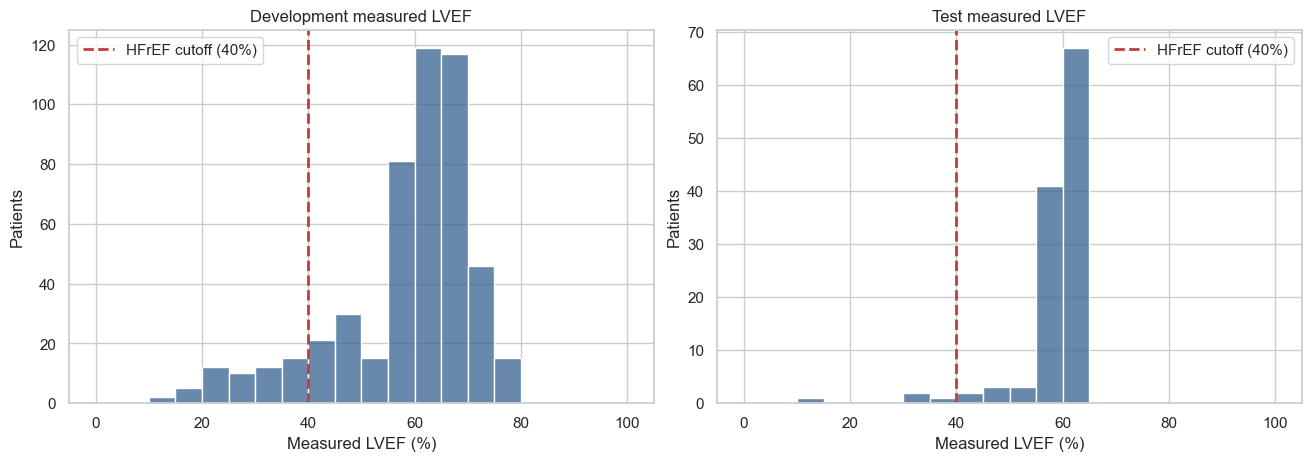

In [8]:
split_summary = (patient_index.groupby(['Split', 'Class'], observed=True)
                 .size().rename('Patients').reset_index())
split_summary['Proportion_within_split'] = (split_summary['Patients'] /
    split_summary.groupby('Split')['Patients'].transform('sum'))
fold_summary = (patient_index.groupby(['Split', 'Fold', 'Class'], observed=True)
                .size().rename('Patients').reset_index())
fold_summary['Proportion_within_fold'] = (fold_summary['Patients'] /
    fold_summary.groupby(['Split', 'Fold'])['Patients'].transform('sum'))
display(split_summary.style.format({'Proportion_within_split': '{:.1%}'}))
display(fold_summary.style.format({'Proportion_within_fold': '{:.1%}'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, split in zip(axes, ('development', 'test')):
    values = patient_index.loc[patient_index.Split == split, 'LVEF_percent']
    sns.histplot(values, bins=np.arange(0, 101, 5), ax=ax, color='#35618f')
    ax.axvline(40, color='#c43b3b', linestyle='--', linewidth=2, label='HFrEF cutoff (40%)')
    ax.set(title=f'{split.title()} measured LVEF', xlabel='Measured LVEF (%)', ylabel='Patients')
    ax.legend()
plt.show()

# index_columns = ['Split', 'Fold', 'Patient_ID', 'LVEF_percent', 'Class',
#                  'ECG_Path', 'PCG_Path', 'Raw_available']
# with pd.option_context('display.max_rows', 25, 'display.max_colwidth', 45):
#     display(patient_index[index_columns].style.format({'LVEF_percent': '{:.1f}%'}))

## Transparent comparison groups

Selections are rebuilt within the requested split scope. Ties use patient ID. The random non-HFrEF sample uses `RANDOM_SEED`; no group uses model confidence or visual appearance.

In [9]:
GROUP_RULES = {
    'all_hfref': 'Every HFrEF patient, increasing measured LVEF',
    'lowest_lvef': f'Lowest {GROUP_N} measured LVEF values',
    'highest_lvef': f'Highest {GROUP_N} measured LVEF values',
    'random_non_hfref': f'Seeded random sample of {GROUP_N} non-HFrEF patients (seed={RANDOM_SEED})',
    'near_cutoff_hfref': f'Closest {GROUP_N} patients at or below the 40% cutoff',
    'near_cutoff_non_hfref': f'Closest {GROUP_N} patients above the 40% cutoff',
}

def build_comparison_groups(scope='development', n=GROUP_N, seed=RANDOM_SEED):
    data = scoped_index(scope).sort_values(['LVEF', 'Patient_ID'], kind='stable')
    hfref = data[data.Label == 1]
    non_hfref = data[data.Label == 0]
    groups = {
        'all_hfref': hfref,
        'lowest_lvef': data.head(n),
        'highest_lvef': data.sort_values(['LVEF', 'Patient_ID'], ascending=[False, True], kind='stable').head(n),
        'random_non_hfref': non_hfref.sample(n=min(n, len(non_hfref)), random_state=seed),
        'near_cutoff_hfref': hfref.assign(distance=0.40-hfref.LVEF).sort_values(['distance', 'Patient_ID']).head(n).drop(columns='distance'),
        'near_cutoff_non_hfref': non_hfref.assign(distance=non_hfref.LVEF-0.40).sort_values(['distance', 'Patient_ID']).head(n).drop(columns='distance'),
    }
    return {name: group.reset_index(drop=True) for name, group in groups.items()}

comparison_groups = build_comparison_groups(DEFAULT_SCOPE)
all_hfref_expected = scoped_index(DEFAULT_SCOPE).query('Label == 1')['Patient_ID'].tolist()
all_hfref_actual = comparison_groups['all_hfref']['Patient_ID'].tolist()
assert len(all_hfref_actual) == len(set(all_hfref_actual))
assert all_hfref_actual == all_hfref_expected
print(f'Complete HFrEF selection verified: {len(all_hfref_actual)} patients, each exactly once.')
for name, group in comparison_groups.items():
    print(f'\n{name}: {GROUP_RULES[name]} [{DEFAULT_SCOPE}; n={len(group)}]')
    display(group[['Patient_ID', 'Split', 'Fold', 'LVEF_percent', 'Class']].style.format({'LVEF_percent': '{:.1f}%'}))

Complete HFrEF selection verified: 60 patients, each exactly once.

all_hfref: Every HFrEF patient, increasing measured LVEF [development; n=60]


,Patient_ID,Split,Fold,LVEF_percent,Class
0,60011313295,development,0,10.0%,HFrEF
1,60012224696,development,1,10.0%,HFrEF
2,60012257804,development,1,15.0%,HFrEF
3,1011468875,development,2,17.0%,HFrEF
4,60012909152,development,4,17.0%,HFrEF
5,60012944614,development,0,17.0%,HFrEF
6,60012358520,development,0,18.0%,HFrEF
7,1011412735,development,2,21.0%,HFrEF
8,60012787426,development,3,21.0%,HFrEF
9,2502271878,development,1,22.0%,HFrEF



lowest_lvef: Lowest 10 measured LVEF values [development; n=10]


,Patient_ID,Split,Fold,LVEF_percent,Class
0,60011313295,development,0,10.0%,HFrEF
1,60012224696,development,1,10.0%,HFrEF
2,60012257804,development,1,15.0%,HFrEF
3,1011468875,development,2,17.0%,HFrEF
4,60012909152,development,4,17.0%,HFrEF
5,60012944614,development,0,17.0%,HFrEF
6,60012358520,development,0,18.0%,HFrEF
7,1011412735,development,2,21.0%,HFrEF
8,60012787426,development,3,21.0%,HFrEF
9,2502271878,development,1,22.0%,HFrEF



highest_lvef: Highest 10 measured LVEF values [development; n=10]


...

,Patient_ID,Split,Fold,LVEF_percent,Class
0,1010442088,development,2,65.0%,non-HFrEF
1,60011099172,development,0,56.0%,non-HFrEF
2,60012899591,development,1,68.0%,non-HFrEF
3,60012858819,development,2,64.0%,non-HFrEF
4,60012410175,development,2,67.0%,non-HFrEF
5,2002660214,development,3,66.0%,non-HFrEF
6,60012696694,development,2,61.0%,non-HFrEF
7,60012263919,development,3,56.0%,non-HFrEF
8,60012474767,development,2,79.0%,non-HFrEF
9,60010635511,development,2,72.0%,non-HFrEF



near_cutoff_hfref: Closest 10 patients at or below the 40% cutoff [development; n=10]


,Patient_ID,Split,Fold,LVEF_percent,Class
0,2502420464,development,3,40.0%,HFrEF
1,60012172071,development,4,40.0%,HFrEF
2,60012192050,development,4,40.0%,HFrEF
3,60012195182,development,3,40.0%,HFrEF
4,1008922101,development,4,39.0%,HFrEF
5,1010358116,development,4,39.0%,HFrEF
6,60012182370,development,0,39.0%,HFrEF
7,60012231951,development,0,39.0%,HFrEF
8,60012251349,development,4,38.0%,HFrEF
9,60012870763,development,3,38.0%,HFrEF



near_cutoff_non_hfref: Closest 10 patients above the 40% cutoff [development; n=10]


,Patient_ID,Split,Fold,LVEF_percent,Class
0,60012153756,development,2,41.0%,non-HFrEF
1,1010243090,development,2,42.0%,non-HFrEF
2,60011997893,development,3,42.0%,non-HFrEF
3,60012205517,development,4,42.0%,non-HFrEF
4,60012233080,development,1,42.0%,non-HFrEF
5,60013315822,development,4,42.0%,non-HFrEF
6,1010119114,development,3,43.0%,non-HFrEF
7,1010830820,development,1,43.0%,non-HFrEF
8,2502279792,development,3,43.0%,non-HFrEF
9,60012221906,development,0,43.0%,non-HFrEF


## Paginated galleries and patient-to-patient comparison

Gallery pages use the same site, time window, representation, and y-axis range within each page. Rebuild groups with `build_comparison_groups('test')` or `build_comparison_groups('all')` to inspect those scopes explicitly.

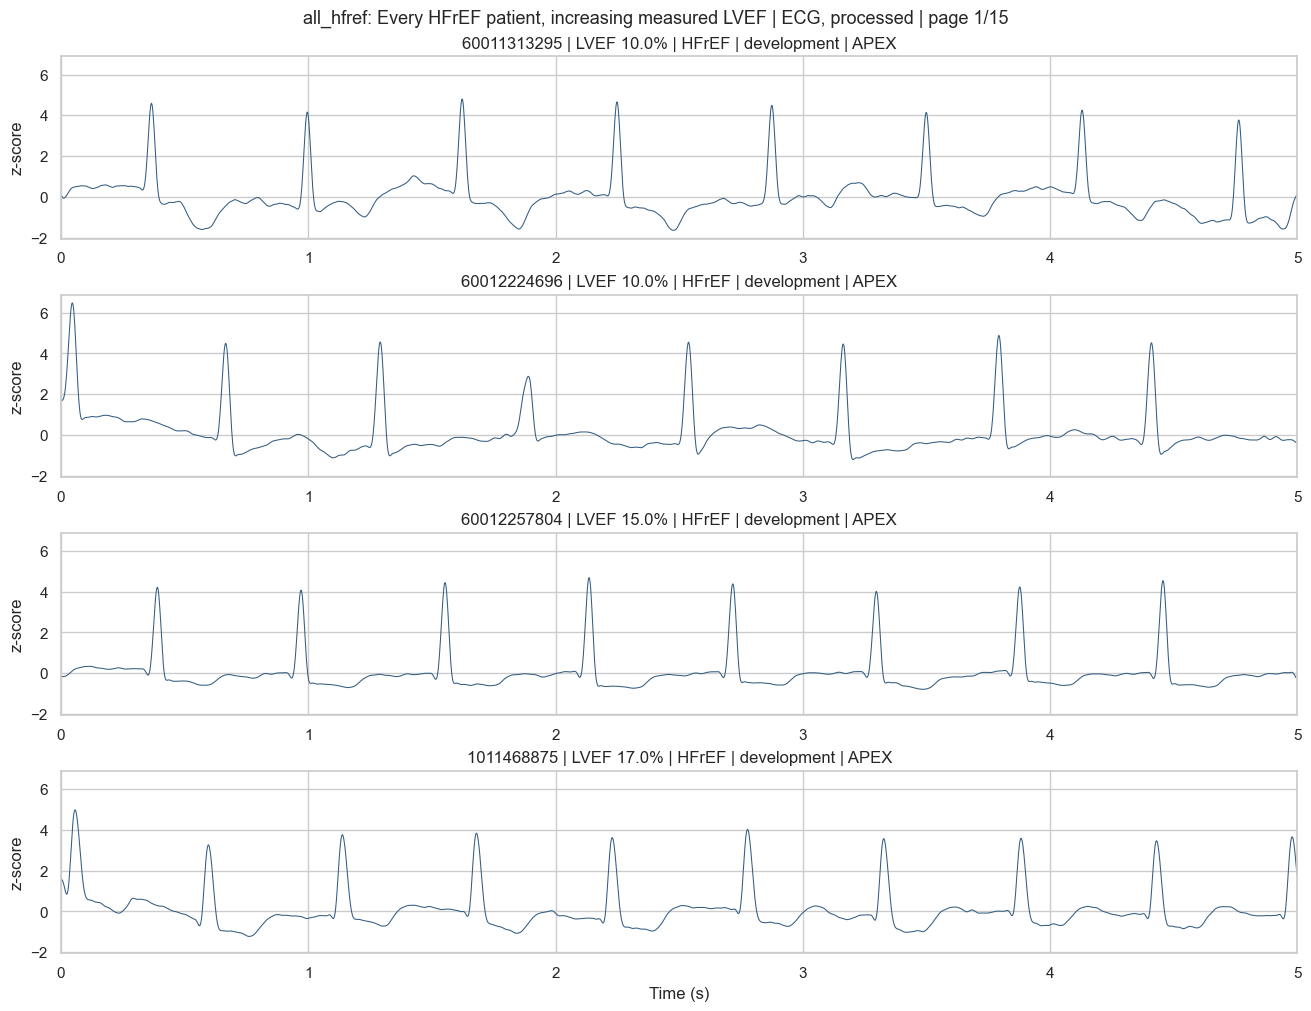

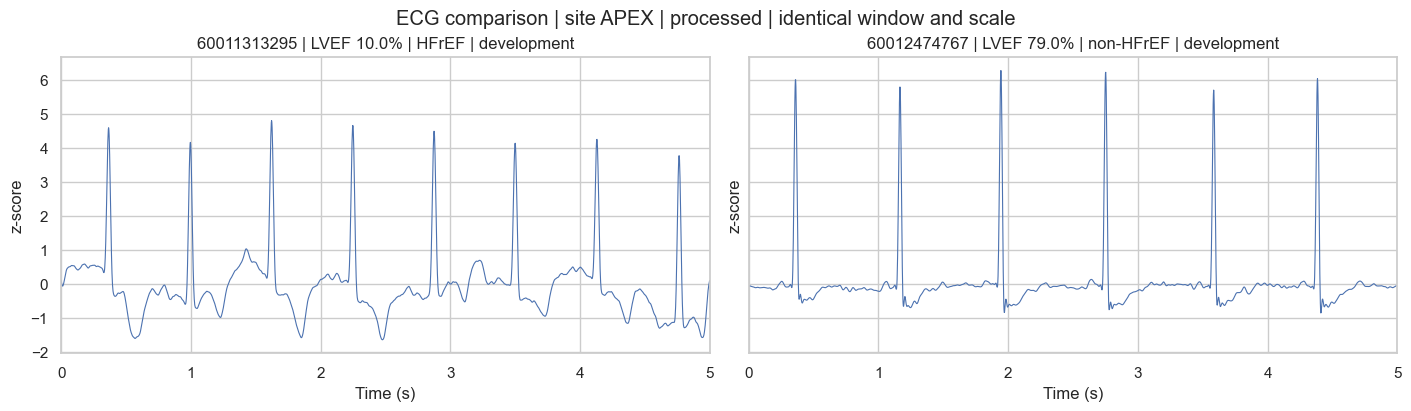

In [10]:
def gallery(group_name='all_hfref', page=1, scope=DEFAULT_SCOPE, modality='ECG',
            site=DEFAULT_SITE, start_s=DEFAULT_START_S, duration_s=DEFAULT_DURATION_S,
            representation='processed', page_size=GALLERY_PAGE_SIZE):
    groups = build_comparison_groups(scope)
    if group_name not in groups:
        raise KeyError(f'Choose one of {list(groups)}')
    group = groups[group_name]
    pages = max(1, int(np.ceil(len(group) / page_size)))
    if page < 1 or page > pages:
        raise ValueError(f'page must be from 1 to {pages}')
    selected = group.iloc[(page - 1) * page_size:page * page_size]
    traces = []
    for row in selected.itertuples(index=False):
        values, fs, unit = load_signal(row.Patient_ID, modality, site, representation, row.Split)
        left, right = int(start_s * fs), int((start_s + duration_s) * fs)
        traces.append((row, np.arange(left, right) / fs, values[left:right], unit))
    if not traces:
        print(f'No patients in {group_name} for {scope}.')
        return None
    y_min = min(np.min(trace[2]) for trace in traces)
    y_max = max(np.max(trace[2]) for trace in traces)
    margin = max((y_max - y_min) * 0.05, 1e-6)
    fig, axes = plt.subplots(len(traces), 1, figsize=(13, 2.5 * len(traces)), squeeze=False, constrained_layout=True)
    for ax, (row, times, values, unit) in zip(axes[:, 0], traces):
        ax.plot(times, values, linewidth=0.75, color='#335c81')
        ax.set(xlim=(start_s, start_s + duration_s), ylim=(y_min - margin, y_max + margin),
               ylabel=unit, title=f'{row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {row.Class} | {row.Split} | {site}')
    axes[-1, 0].set_xlabel('Time (s)')
    fig.suptitle(f'{group_name}: {GROUP_RULES[group_name]} | {modality}, {representation} | page {page}/{pages}', fontsize=13)
    plt.show()
    return fig

def compare_patients(patient_a, patient_b, modality='ECG', site=DEFAULT_SITE,
                     start_s=DEFAULT_START_S, duration_s=DEFAULT_DURATION_S, representation='processed'):
    rows = [patient_row(patient_a), patient_row(patient_b)]
    loaded = []
    for row in rows:
        values, fs, unit = load_signal(row.Patient_ID, modality, site, representation, row.Split)
        left, right = int(start_s * fs), int((start_s + duration_s) * fs)
        loaded.append((row, np.arange(left, right) / fs, values[left:right], unit))
    y_min = min(np.min(item[2]) for item in loaded)
    y_max = max(np.max(item[2]) for item in loaded)
    margin = max((y_max - y_min) * 0.05, 1e-6)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True, sharey=True)
    for ax, (row, times, values, unit) in zip(axes, loaded):
        ax.plot(times, values, linewidth=0.8)
        ax.set(xlabel='Time (s)', ylabel=unit, xlim=(start_s, start_s + duration_s), ylim=(y_min-margin, y_max+margin),
               title=f'{row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {row.Class} | {row.Split}')
    fig.suptitle(f'{modality} comparison | site {site} | {representation} | identical window and scale')
    plt.show()
    return fig

_ = gallery('all_hfref', page=1, scope=DEFAULT_SCOPE)
_ = compare_patients(comparison_groups['lowest_lvef'].iloc[0].Patient_ID,
                     comparison_groups['highest_lvef'].iloc[0].Patient_ID)

## Raw, filtered, and processed representations

Use this comparison to separate recording-scale effects from standardized morphology. Filtering is for display only and does not modify saved data. Raw and filtered panels share their scale; processed values use a separate z-score scale.

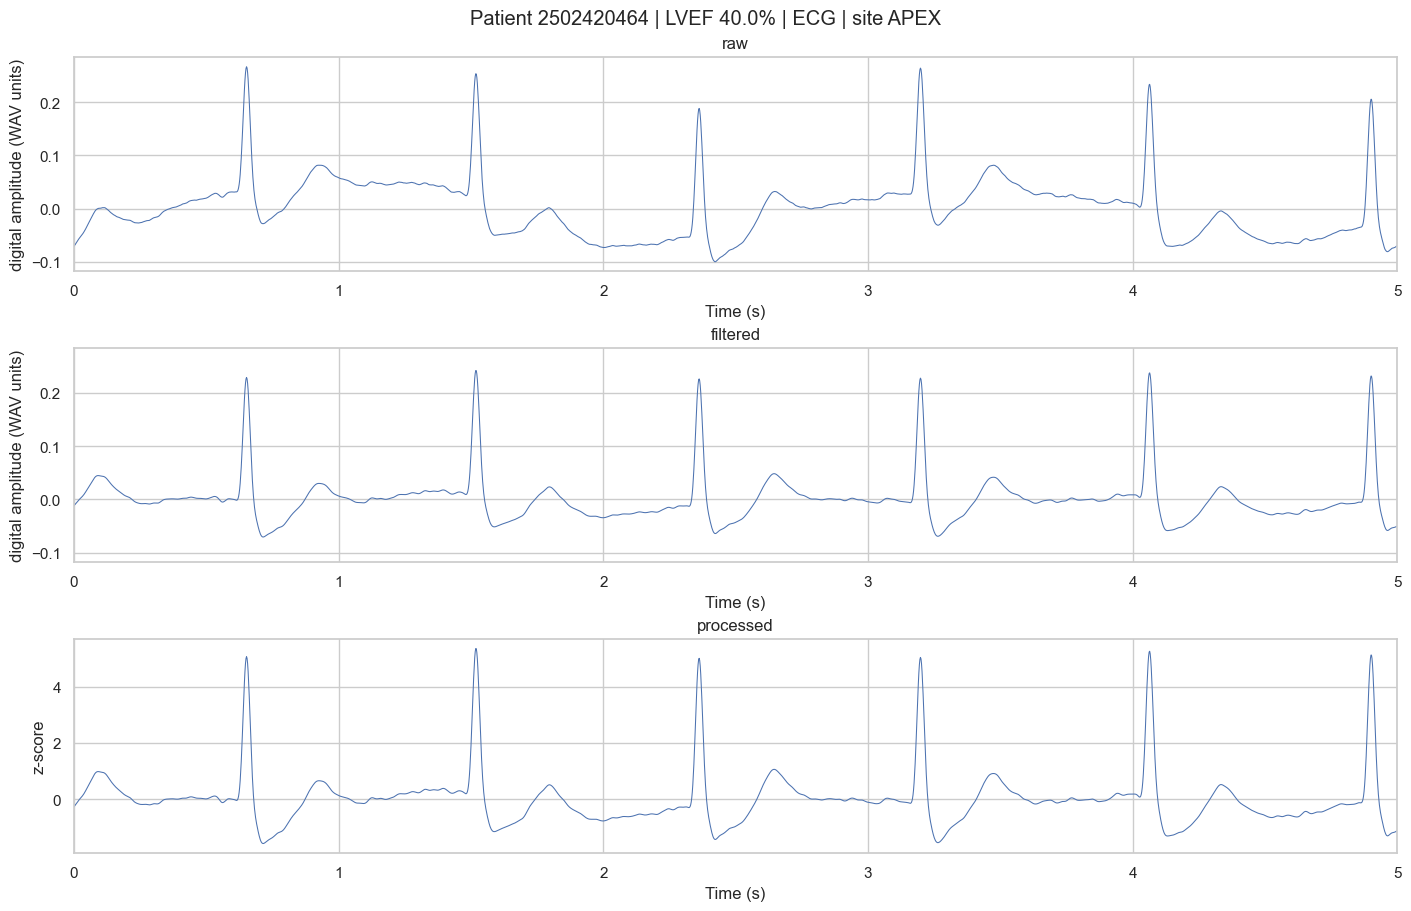

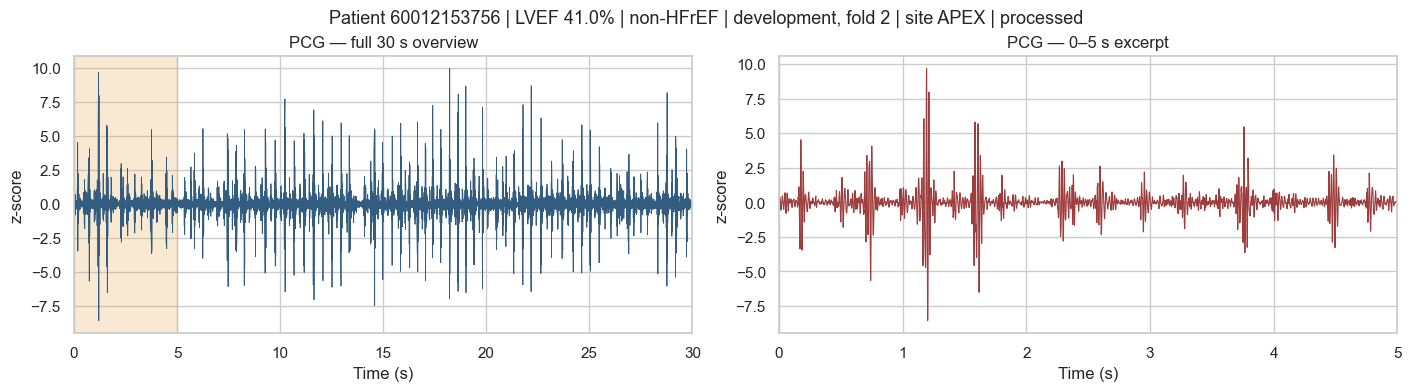

In [11]:
def compare_representations(patient_id, modality='ECG', site=DEFAULT_SITE,
                            start_s=DEFAULT_START_S, duration_s=DEFAULT_DURATION_S):
    row = patient_row(patient_id)
    available = ['processed'] if not row.Raw_available else ['raw', 'filtered', 'processed']
    fig, axes = plt.subplots(len(available), 1, figsize=(14, 3 * len(available)), squeeze=False, constrained_layout=True)
    raw_limits = None
    for ax, representation in zip(axes[:, 0], available):
        values, fs, unit = load_signal(row.Patient_ID, modality, site, representation, row.Split)
        left, right = int(start_s * fs), int((start_s + duration_s) * fs)
        excerpt = values[left:right]
        times = np.arange(left, right) / fs
        ax.plot(times, excerpt, linewidth=0.75)
        ax.set(xlabel='Time (s)', ylabel=unit, xlim=(start_s, start_s + duration_s), title=representation)
        if representation == 'raw':
            raw_limits = ax.get_ylim()
        elif representation == 'filtered' and raw_limits is not None:
            ax.set_ylim(raw_limits)
    fig.suptitle(f'Patient {row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {modality} | site {site}')
    plt.show()
    return fig

RAW_COMPARISON_PATIENT = comparison_groups['near_cutoff_hfref'].iloc[0].Patient_ID
_ = compare_representations(RAW_COMPARISON_PATIENT, modality='ECG')

# Representative PCG boundary case, using the same default window.
PCG_BOUNDARY_PATIENT = comparison_groups['near_cutoff_non_hfref'].iloc[0].Patient_ID
_ = plot_patient(PCG_BOUNDARY_PATIENT, modality='PCG', site=DEFAULT_SITE,
                 start_s=DEFAULT_START_S, duration_s=DEFAULT_DURATION_S)

## Consistent multi-window comparison

This view checks whether an impression recurs at 0–5, 10–15, and 20–25 seconds. Every window uses full-resolution samples and one shared amplitude range containing all displayed values. Processed values remain z-scores; raw values remain uncalibrated WAV units.

In [12]:
def plot_patient_windows(patient_id, modality='ECG', site='APEX', starts=REVIEW_WINDOWS,
                         duration_s=5.0, representation='processed'):
    row = patient_row(patient_id)
    values, fs, unit = load_signal(row.Patient_ID, modality, site, representation, row.Split)
    windows = []
    for start_s in starts:
        if start_s < 0 or duration_s <= 0 or start_s + duration_s > DURATION_SECONDS:
            raise ValueError(f'Every window must lie within 0–{DURATION_SECONDS} seconds.')
        left, right = int(round(start_s * fs)), int(round((start_s + duration_s) * fs))
        windows.append((start_s, np.arange(left, right) / fs, values[left:right]))
    y_min = min(window[2].min() for window in windows)
    y_max = max(window[2].max() for window in windows)
    margin = max(0.05 * (y_max - y_min), 1e-6)
    fig, axes = plt.subplots(len(windows), 1, figsize=(13, 2.7 * len(windows)), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, (start_s, times, excerpt) in zip(axes, windows):
        ax.plot(times, excerpt, linewidth=0.8)
        ax.set(xlim=(start_s, start_s + duration_s), ylim=(y_min-margin, y_max+margin),
               xlabel='Time (s)', ylabel=unit, title=f'{start_s:g}–{start_s+duration_s:g} s')
    fig.suptitle(f'{row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {modality} | {site} | {representation}')
    plt.show()
    return fig

## Candidate-beat detection

The detector uses SciPy peak prominence, checks both signal polarities, favors sharp recurring peaks, and flags insufficient peaks or implausible intervals. The markers are alignment candidates, not validated clinical R-wave annotations. No clinical QRS duration is computed.

The diagnostic plot keeps the ECG at full resolution. Review these overlays before interpreting any derived timing or median-beat measurement.

In [13]:
def plot_detected_peaks(patient_id, site='APEX', start_s=0.0, duration_s=10.0):
    row = patient_row(patient_id)
    values, fs, unit = load_signal(row.Patient_ID, 'ECG', site, 'processed', row.Split)
    if start_s < 0 or duration_s <= 0 or start_s + duration_s > DURATION_SECONDS:
        raise ValueError(f'Window must lie within 0–{DURATION_SECONDS} seconds.')
    detection = detect_ecg_beats(values, fs, **DETECTOR_SETTINGS)
    left, right = int(round(start_s * fs)), int(round((start_s + duration_s) * fs))
    visible = detection.peaks[(detection.peaks >= left) & (detection.peaks < right)]
    fig, ax = plt.subplots(figsize=(13, 3.5), constrained_layout=True)
    ax.plot(np.arange(left, right) / fs, values[left:right], linewidth=0.8)
    ax.scatter(visible / fs, values[visible], color='crimson', s=28, zorder=3, label='candidate peak')
    ax.set(xlim=(start_s, start_s + duration_s), xlabel='Time (s)', ylabel=unit,
           title=(f'{row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {site} | '
                  f'{detection.status} | polarity {detection.polarity:+d}'))
    ax.legend(loc='upper right')
    plt.show()
    return detection, fig

## Median-beat morphology and within-patient variability

Candidate peaks anchor fixed windows from 0.20 seconds before to 0.28 seconds after the peak by default (configured in BEAT_PRE_SECONDS and BEAT_POST_SECONDS). Incomplete boundary windows are excluded and counted. Individual beats stay in the existing per-recording z-score representation; no extra centering, scaling, polarity flipping, or time warping is applied. The median and interquartile envelope summarize recurring shape. Beat-to-median variability is the median root-mean-square deviation of individual beats from that median waveform.

In [14]:
def median_beat_data(patient_id, site='APEX'):
    row = patient_row(patient_id)
    values, fs, _ = load_signal(row.Patient_ID, 'ECG', site, 'processed', row.Split)
    detection = detect_ecg_beats(values, fs, **DETECTOR_SETTINGS)
    beats, usable_peaks = extract_aligned_beats(
        values, detection.peaks, fs,
        pre_seconds=BEAT_PRE_SECONDS, post_seconds=BEAT_POST_SECONDS)
    times = np.arange(beats.shape[1]) / fs - BEAT_PRE_SECONDS
    return row, detection, beats, usable_peaks, times

def plot_median_beat(patient_id, site='APEX'):
    row, detection, beats, usable_peaks, times = median_beat_data(patient_id, site)
    if not len(beats):
        raise ValueError(f'No complete candidate-beat windows for {patient_id}, {site}.')
    median = np.median(beats, axis=0)
    lower, upper = np.percentile(beats, [25, 75], axis=0)
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    ax.plot(times, beats.T, color='#7893ad', alpha=0.10, linewidth=0.5)
    ax.fill_between(times, lower, upper, color='#e49b36', alpha=0.30, label='interquartile envelope')
    ax.plot(times, median, color='#9b2f2f', linewidth=2, label='median beat')
    ax.axvline(0, color='black', linestyle=':', linewidth=1, label='candidate peak')
    ax.set(xlabel='Time relative to candidate peak (s)', ylabel='z-score',
           title=(f'{row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {site} | '
                  f'{len(usable_peaks)}/{len(detection.peaks)} usable beats | {detection.status}'))
    ax.legend()
    plt.show()
    return fig

def compare_median_beats(patient_ids, site='APEX'):
    prepared = [median_beat_data(patient_id, site) for patient_id in patient_ids]
    medians = [np.median(item[2], axis=0) for item in prepared if len(item[2])]
    if len(medians) != len(prepared):
        raise ValueError('At least one selected recording has no complete beat windows.')
    y_min, y_max = min(x.min() for x in medians), max(x.max() for x in medians)
    margin = max(0.05 * (y_max-y_min), 1e-6)
    fig, axes = plt.subplots(len(prepared), 1, figsize=(11, 2.8*len(prepared)), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, (row, detection, beats, usable, times), median in zip(axes, prepared, medians):
        lower, upper = np.percentile(beats, [25, 75], axis=0)
        ax.fill_between(times, lower, upper, alpha=.25)
        ax.plot(times, median, linewidth=1.8)
        ax.axvline(0, color='black', linestyle=':', linewidth=1)
        ax.set(ylim=(y_min-margin, y_max+margin), ylabel='z-score',
               title=f'{row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {len(usable)} usable | {detection.status}')
    axes[-1].set_xlabel('Time relative to candidate peak (s)')
    fig.suptitle(f'Median-beat comparison | site {site} | shared scale')
    plt.show()
    return fig

## Development cohort feature table

The table has one row per patient and acquisition site. It retains every development patient and all four sites. Failed detector checks remain as flagged rows, with timing and morphology measurements left missing rather than guessed. Heart rate and interval variability are short-recording estimates. Quality measures come from raw ECG: baseline and high-frequency component RMS are divided by total centered-signal RMS; full-scale samples and the longest exactly constant run are strict acquisition proxies.

Set `RUN_COHORT_ANALYSIS = True` to rebuild the file explicitly. Routine notebook runs load the existing analysis output without scanning all recordings.

In [15]:
FEATURE_OUTPUT_PATH = ANALYSIS_OUTPUT_DIR / 'ecg_development_patient_site_features.csv'
WINDOW_OUTPUT_PATH = ANALYSIS_OUTPUT_DIR / 'ecg_development_window_features.csv'
RUN_COHORT_ANALYSIS = False

def compute_development_feature_table():
    rows = []
    development = scoped_index('development')
    for patient in development.itertuples(index=False):
        processed = _load_processed(patient.ECG_Path)
        for site_index, site in enumerate(CHANNEL_ORDER):
            raw, fs, _ = load_signal(patient.Patient_ID, 'ECG', site, 'raw', 'development')
            measurements = summarize_ecg(
                processed[site_index], raw, fs,
                pre_seconds=BEAT_PRE_SECONDS, post_seconds=BEAT_POST_SECONDS,
                detector_kwargs=DETECTOR_SETTINGS)
            rows.append({
                'Patient_ID': patient.Patient_ID, 'Fold': patient.Fold,
                'LVEF': patient.LVEF, 'Label': patient.Label, 'Site': site,
                **measurements,
            })
    return pd.DataFrame(rows)

def compute_window_feature_table():
    rows = []
    duration_s = 5.0
    for patient in scoped_index('development').itertuples(index=False):
        processed = _load_processed(patient.ECG_Path)
        for site_index, site in enumerate(CHANNEL_ORDER):
            for start_s in REVIEW_WINDOWS:
                left, right = int(start_s * ECG_FS), int((start_s + duration_s) * ECG_FS)
                measurements = summarize_processed_ecg(
                    processed[site_index, left:right], ECG_FS,
                    pre_seconds=BEAT_PRE_SECONDS, post_seconds=BEAT_POST_SECONDS,
                    detector_kwargs=DETECTOR_SETTINGS)
                rows.append({
                    'Patient_ID': patient.Patient_ID, 'Fold': patient.Fold,
                    'LVEF': patient.LVEF, 'Label': patient.Label, 'Site': site,
                    'Start_s': start_s, 'Duration_s': duration_s, **measurements,
                })
    return pd.DataFrame(rows)

if RUN_COHORT_ANALYSIS:
    ANALYSIS_OUTPUT_DIR.mkdir(exist_ok=True)
    site_features = compute_development_feature_table()
    window_features = compute_window_feature_table()
    site_features.to_csv(FEATURE_OUTPUT_PATH, index=False)
    window_features.to_csv(WINDOW_OUTPUT_PATH, index=False)
else:
    if not FEATURE_OUTPUT_PATH.is_file() or not WINDOW_OUTPUT_PATH.is_file():
        raise FileNotFoundError('Set RUN_COHORT_ANALYSIS = True once to create both analysis tables.')
    site_features = pd.read_csv(FEATURE_OUTPUT_PATH, dtype={'Patient_ID': str})
    window_features = pd.read_csv(WINDOW_OUTPUT_PATH, dtype={'Patient_ID': str})

assert len(site_features) == 500 * len(CHANNEL_ORDER)
assert site_features.Patient_ID.nunique() == 500
assert site_features.groupby('Patient_ID').Site.nunique().eq(len(CHANNEL_ORDER)).all()
assert len(window_features) == 500 * len(CHANNEL_ORDER) * len(REVIEW_WINDOWS)

flagged_detections = site_features[site_features.detection_status.ne('ok')]
display(pd.DataFrame({
    'Rows': [len(site_features)],
    'Patients': [site_features.Patient_ID.nunique()],
    'Valid detections': [site_features.detection_status.eq('ok').sum()],
    'Flagged detections': [len(flagged_detections)],
    'Strict raw-quality flags': [site_features.quality_status.ne('no_strict_flag').sum()],
}))
display(flagged_detections[[
    'Patient_ID', 'LVEF', 'Label', 'Fold', 'Site', 'detected_beats',
    'plausible_rr_fraction', 'detection_status', 'quality_status',
]])

,Rows,Patients,Valid detections,Flagged detections,Strict raw-quality flags
0,2000,500,1997,3,15


,Patient_ID,LVEF,Label,Fold,Site,detected_beats,plausible_rr_fraction,detection_status,quality_status
31,1011412735,0.21,1,2,RUSB,2,1.000000,insufficient_peaks,full_scale_samples
445,60012867470,0.50,0,4,LLSB,13,0.666667,implausible_intervals,full_scale_samples
606,60011958231,0.57,0,2,LUSB,15,0.642857,implausible_intervals,full_scale_samples


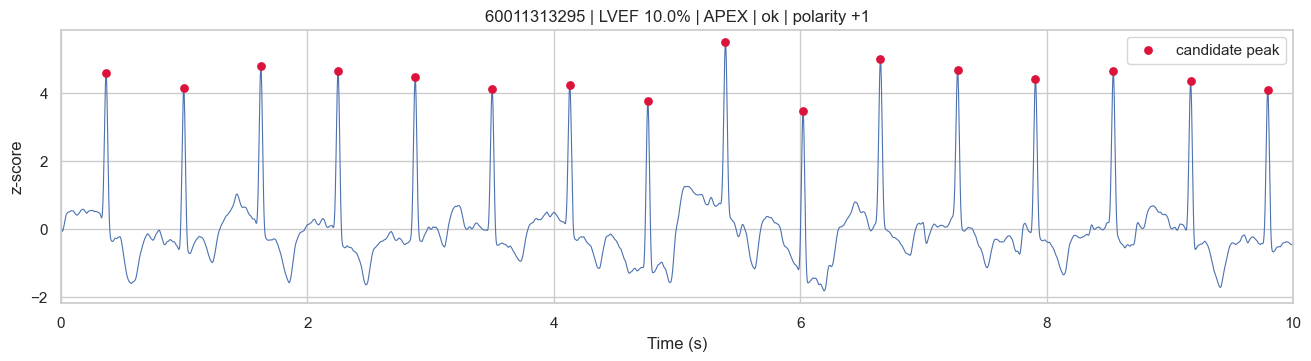

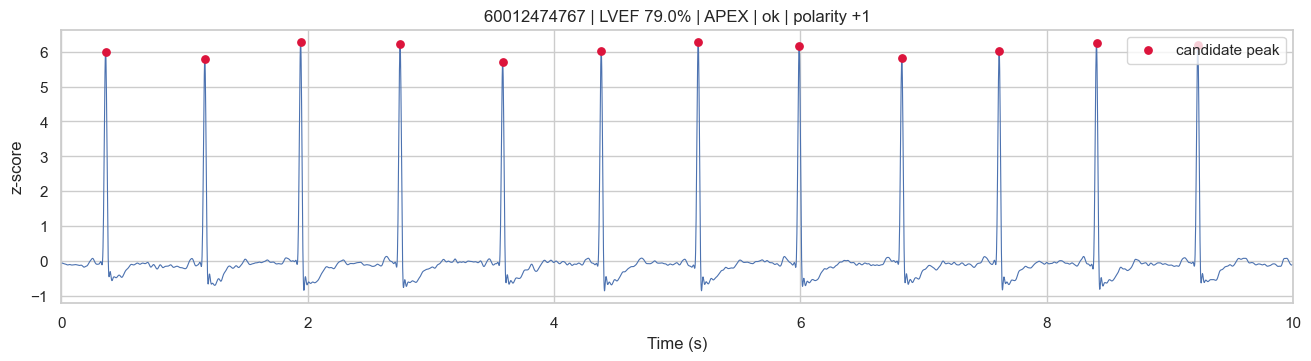

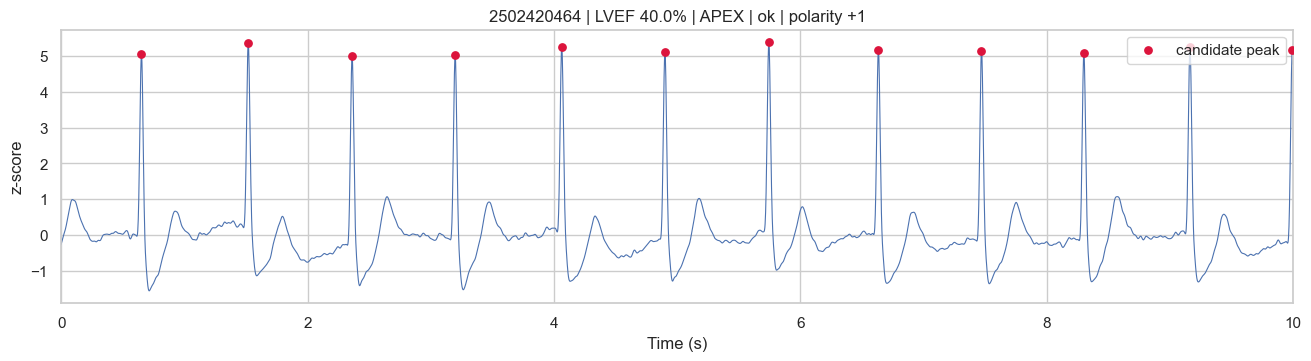

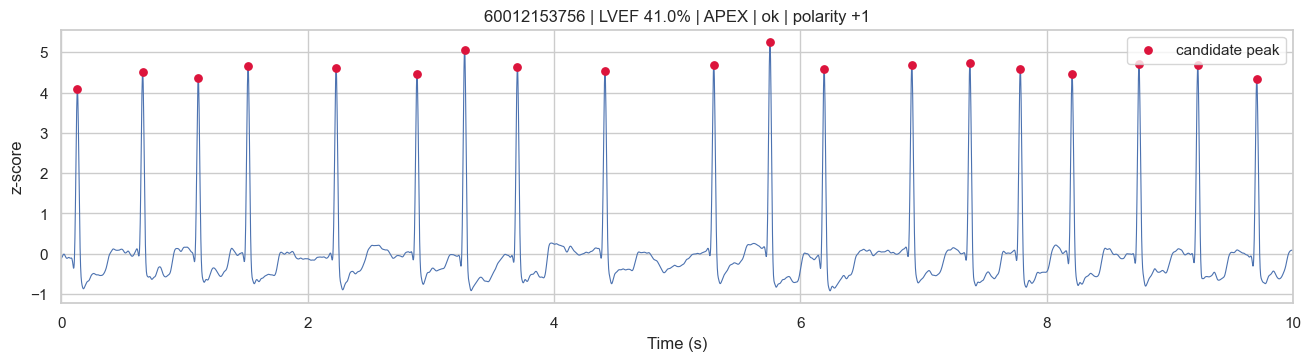

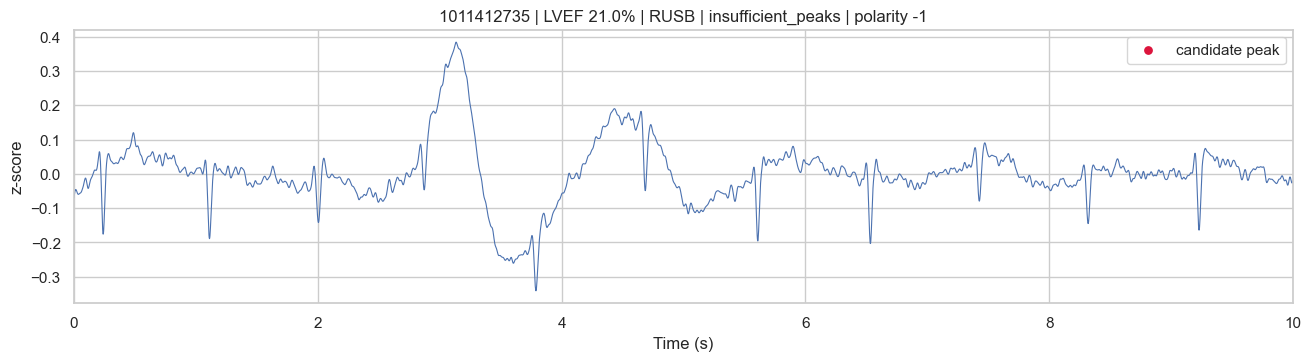

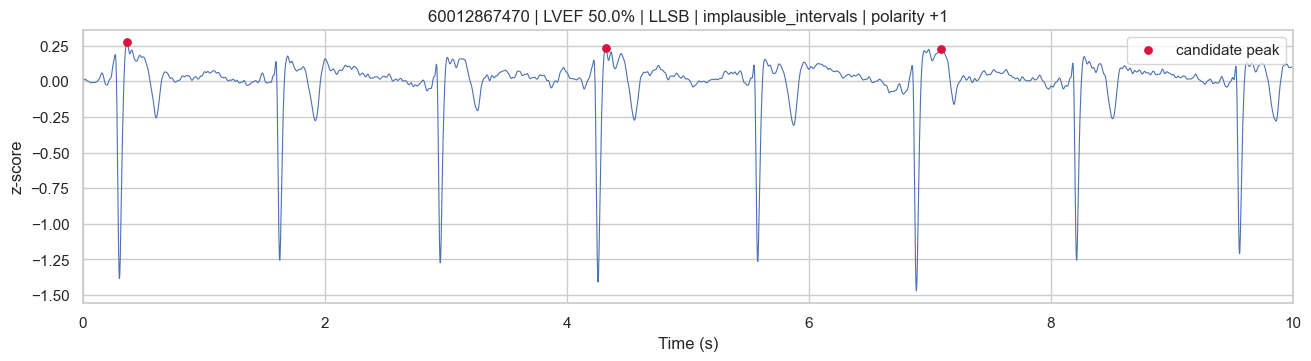

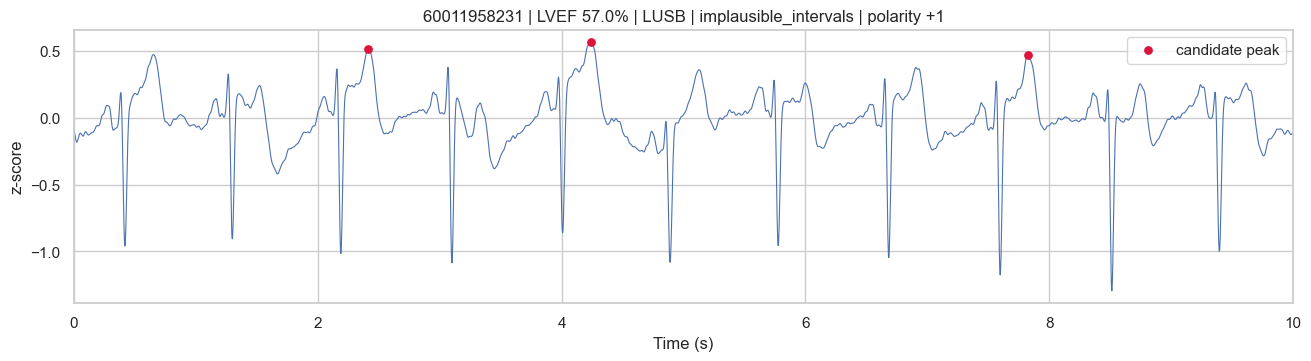

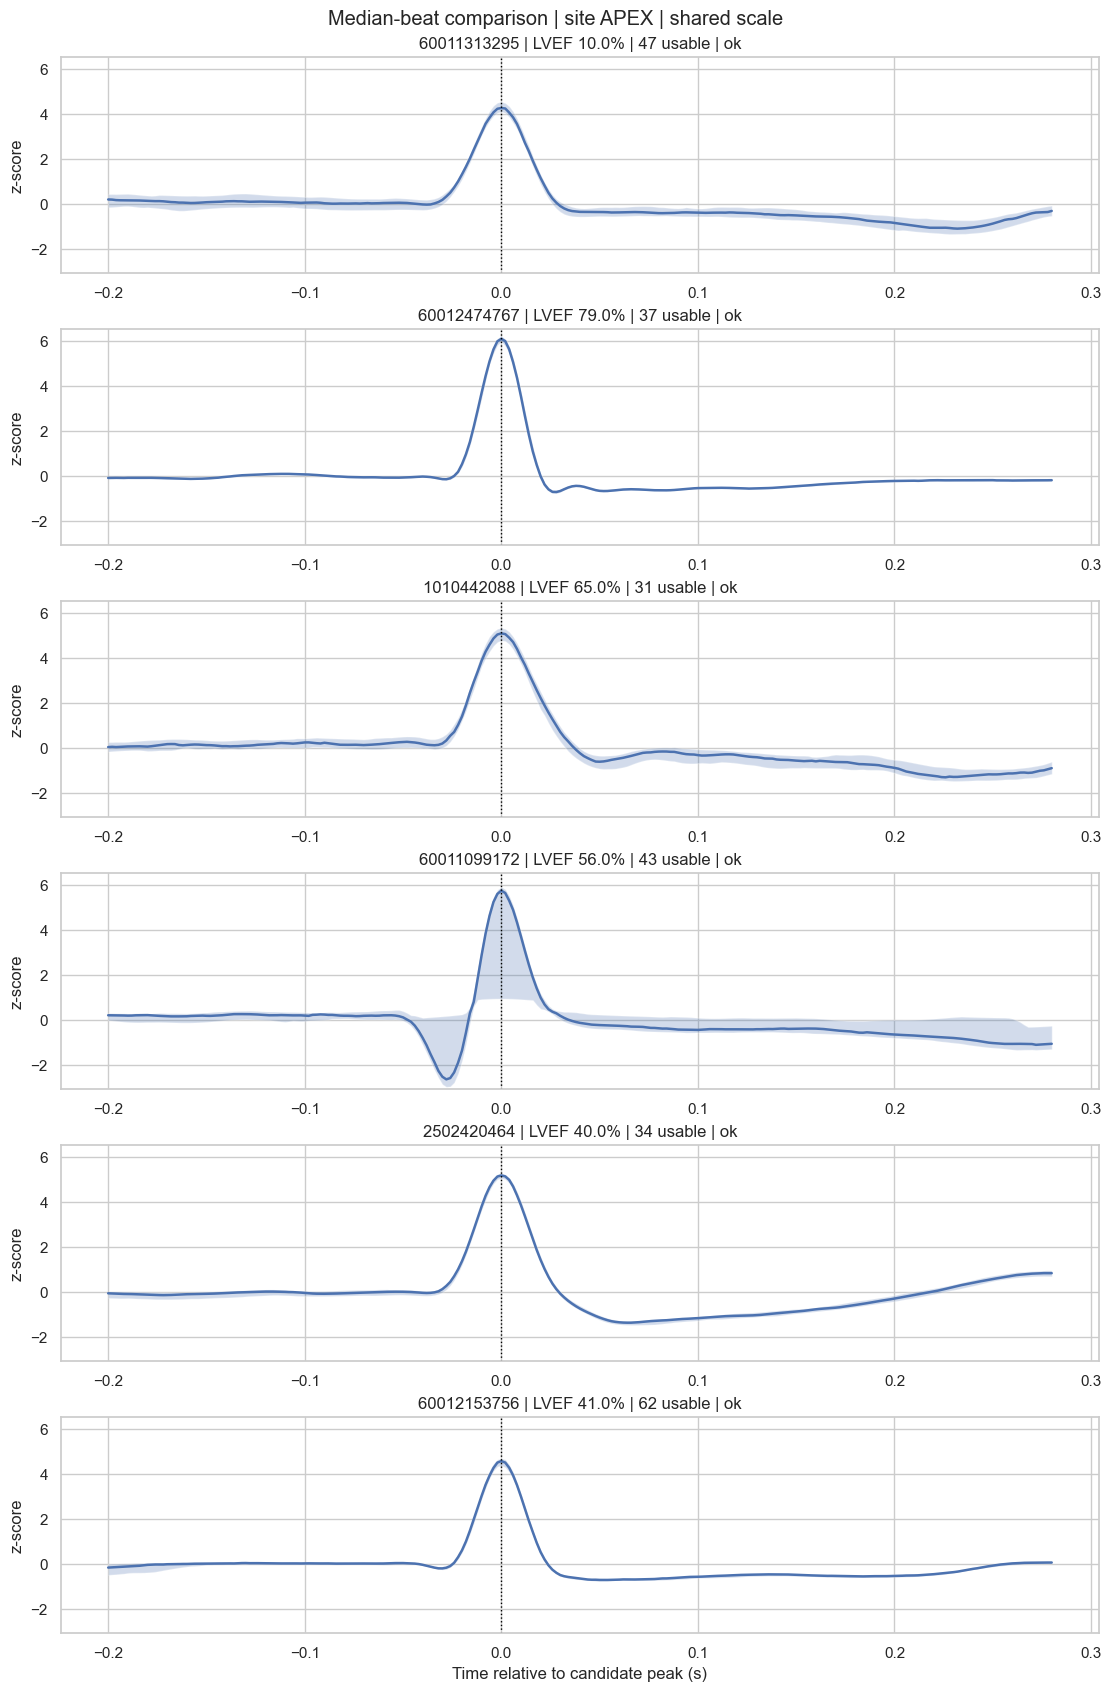

In [16]:
# Diagnostic examples: LVEF extremes, both sides of 40%, and every flagged detector row.
diagnostic_ids = [
    comparison_groups['lowest_lvef'].iloc[0].Patient_ID,
    comparison_groups['highest_lvef'].iloc[0].Patient_ID,
    comparison_groups['near_cutoff_hfref'].iloc[0].Patient_ID,
    comparison_groups['near_cutoff_non_hfref'].iloc[0].Patient_ID,
]
diagnostic_pairs = [(patient_id, 'APEX') for patient_id in diagnostic_ids]
diagnostic_pairs.extend(flagged_detections[['Patient_ID', 'Site']].itertuples(index=False, name=None))
diagnostic_pairs = list(dict.fromkeys(diagnostic_pairs))
for patient_id, site in diagnostic_pairs:
    _detection, _figure = plot_detected_peaks(patient_id, site=site, duration_s=10.0)

median_comparison_ids = [
    comparison_groups['lowest_lvef'].iloc[0].Patient_ID,
    comparison_groups['highest_lvef'].iloc[0].Patient_ID,
    comparison_groups['random_non_hfref'].iloc[0].Patient_ID,
    comparison_groups['random_non_hfref'].iloc[1].Patient_ID,
    comparison_groups['near_cutoff_hfref'].iloc[0].Patient_ID,
    comparison_groups['near_cutoff_non_hfref'].iloc[0].Patient_ID,
]
_ = compare_median_beats(median_comparison_ids, site='APEX')

## Patient-level exploratory comparisons

Site-specific rows remain available in `site_features`. For overall comparisons, this section takes the median across valid sites for each patient and records the number of contributing sites. Bootstrap intervals resample patients within each class. They describe uncertainty in this development cohort and are not confirmatory inference.

In [17]:
FEATURE_LABELS = {
    'estimated_heart_rate_bpm': 'Estimated heart rate (bpm)',
    'rr_cv_percent_short_recording': 'Interval CV, short recording (%)',
    'beat_to_median_rmse_z': 'Beat-to-median RMSE (z-score)',
    'median_beat_peak_to_peak_z': 'Median-beat peak-to-peak (z-score)',
    'median_beat_post_pre_rms_ratio': 'Post/pre candidate-peak RMS ratio',
    'baseline_drift_rms_ratio': 'Raw baseline RMS / total RMS',
    'high_frequency_rms_ratio': 'Raw >40 Hz RMS / total RMS',
}
valid_site_features = site_features[site_features.detection_status.eq('ok')].copy()
patient_features = (valid_site_features.groupby(['Patient_ID', 'Fold', 'LVEF', 'Label'], as_index=False)
                    [list(FEATURE_LABELS)].median())
valid_sites = valid_site_features.groupby('Patient_ID').Site.nunique().rename('valid_sites')
patient_features = patient_features.join(valid_sites, on='Patient_ID')

missingness = pd.DataFrame({
    'Feature': list(FEATURE_LABELS),
    'Missing_patient_values': [patient_features[name].isna().sum() for name in FEATURE_LABELS],
})
display(missingness)

def bootstrap_median_difference(data, feature, repeats=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    groups = [data.loc[data.Label.eq(label), feature].dropna().to_numpy() for label in (1, 0)]
    if any(len(group) == 0 for group in groups):
        return np.nan, np.nan, np.nan
    observed = np.median(groups[0]) - np.median(groups[1])
    draws = np.empty(repeats)
    for index in range(repeats):
        draws[index] = (
            np.median(rng.choice(groups[0], len(groups[0]), replace=True)) -
            np.median(rng.choice(groups[1], len(groups[1]), replace=True)))
    low, high = np.percentile(draws, [2.5, 97.5])
    return observed, low, high

effect_rows = []
for feature, label in FEATURE_LABELS.items():
    difference, low, high = bootstrap_median_difference(patient_features, feature)
    effect_rows.append({
        'Feature': feature, 'Display_name': label,
        'HFrEF_median': patient_features.loc[patient_features.Label.eq(1), feature].median(),
        'non_HFrEF_median': patient_features.loc[patient_features.Label.eq(0), feature].median(),
        'Median_difference_HFrEF_minus_non': difference,
        'Bootstrap_95%_low': low, 'Bootstrap_95%_high': high,
        'HFrEF_patients': patient_features.loc[patient_features.Label.eq(1), feature].notna().sum(),
        'non_HFrEF_patients': patient_features.loc[patient_features.Label.eq(0), feature].notna().sum(),
    })
effect_table = pd.DataFrame(effect_rows)
display(effect_table.style.format({
    'HFrEF_median': '{:.3f}', 'non_HFrEF_median': '{:.3f}',
    'Median_difference_HFrEF_minus_non': '{:.3f}',
    'Bootstrap_95%_low': '{:.3f}', 'Bootstrap_95%_high': '{:.3f}',
}))

,Feature,Missing_patient_values
0,estimated_heart_rate_bpm,0
1,rr_cv_percent_short_recording,0
2,beat_to_median_rmse_z,0
3,median_beat_peak_to_peak_z,0
4,median_beat_post_pre_rms_ratio,0
5,baseline_drift_rms_ratio,0
6,high_frequency_rms_ratio,0


,Feature,Display_name,HFrEF_median,non_HFrEF_median,Median_difference_HFrEF_minus_non,Bootstrap_95%_low,Bootstrap_95%_high,HFrEF_patients,non_HFrEF_patients
0,estimated_heart_rate_bpm,Estimated heart rate (bpm),83.111,74.351,8.760,0.329,14.494,60,440
1,rr_cv_percent_short_recording,"Interval CV, short recording (%)",8.125,16.693,-8.568,-12.552,-2.078,60,440
2,beat_to_median_rmse_z,Beat-to-median RMSE (z-score),0.183,0.245,-0.062,-0.092,-0.024,60,440
3,median_beat_peak_to_peak_z,Median-beat peak-to-peak (z-score),5.574,6.347,-0.773,-0.994,-0.423,60,440
4,median_beat_post_pre_rms_ratio,Post/pre candidate-peak RMS ratio,1.000,1.062,-0.062,-0.095,0.009,60,440
5,baseline_drift_rms_ratio,Raw baseline RMS / total RMS,0.253,0.308,-0.055,-0.090,-0.014,60,440
6,high_frequency_rms_ratio,Raw >40 Hz RMS / total RMS,0.010,0.014,-0.004,-0.006,-0.003,60,440


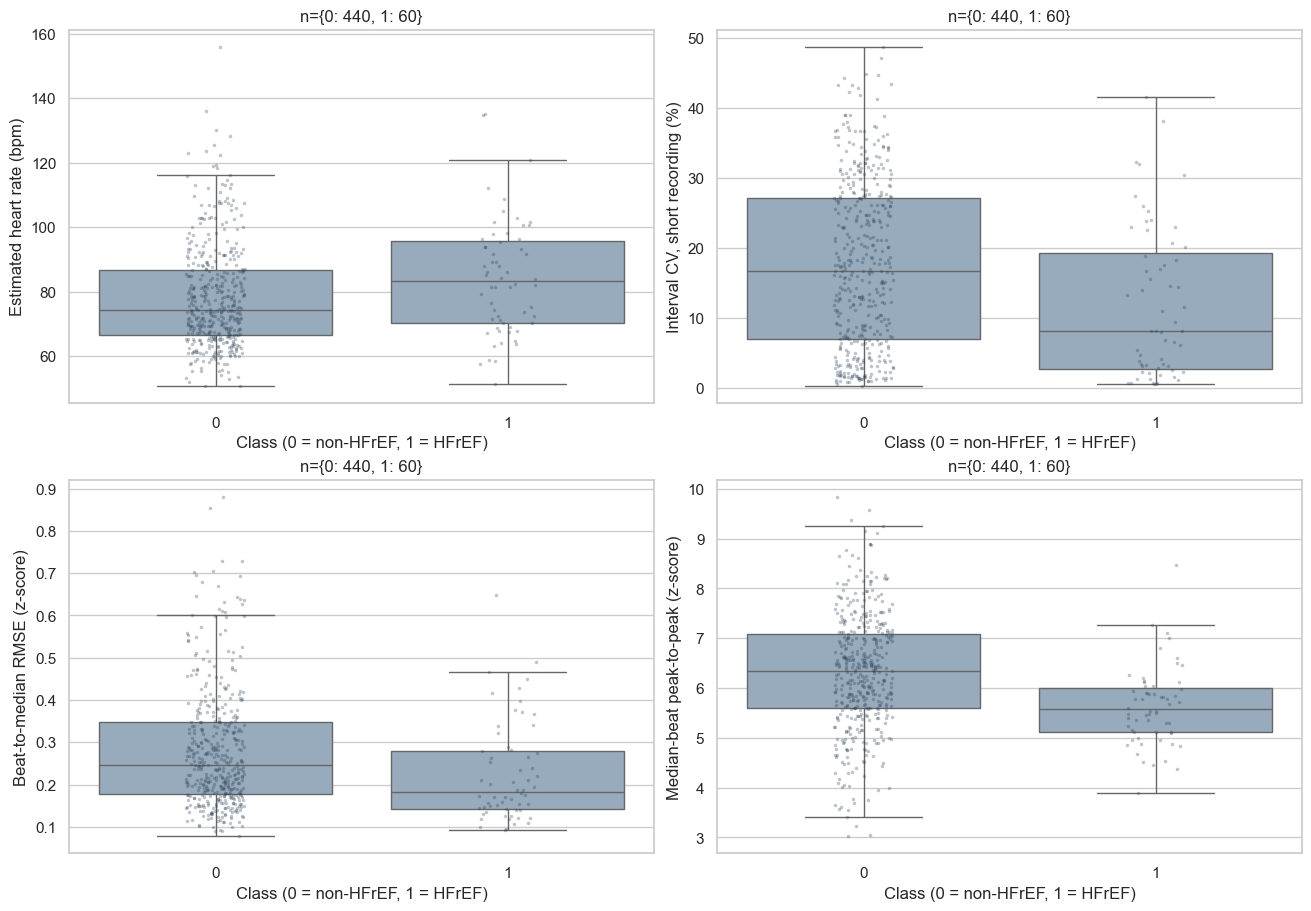

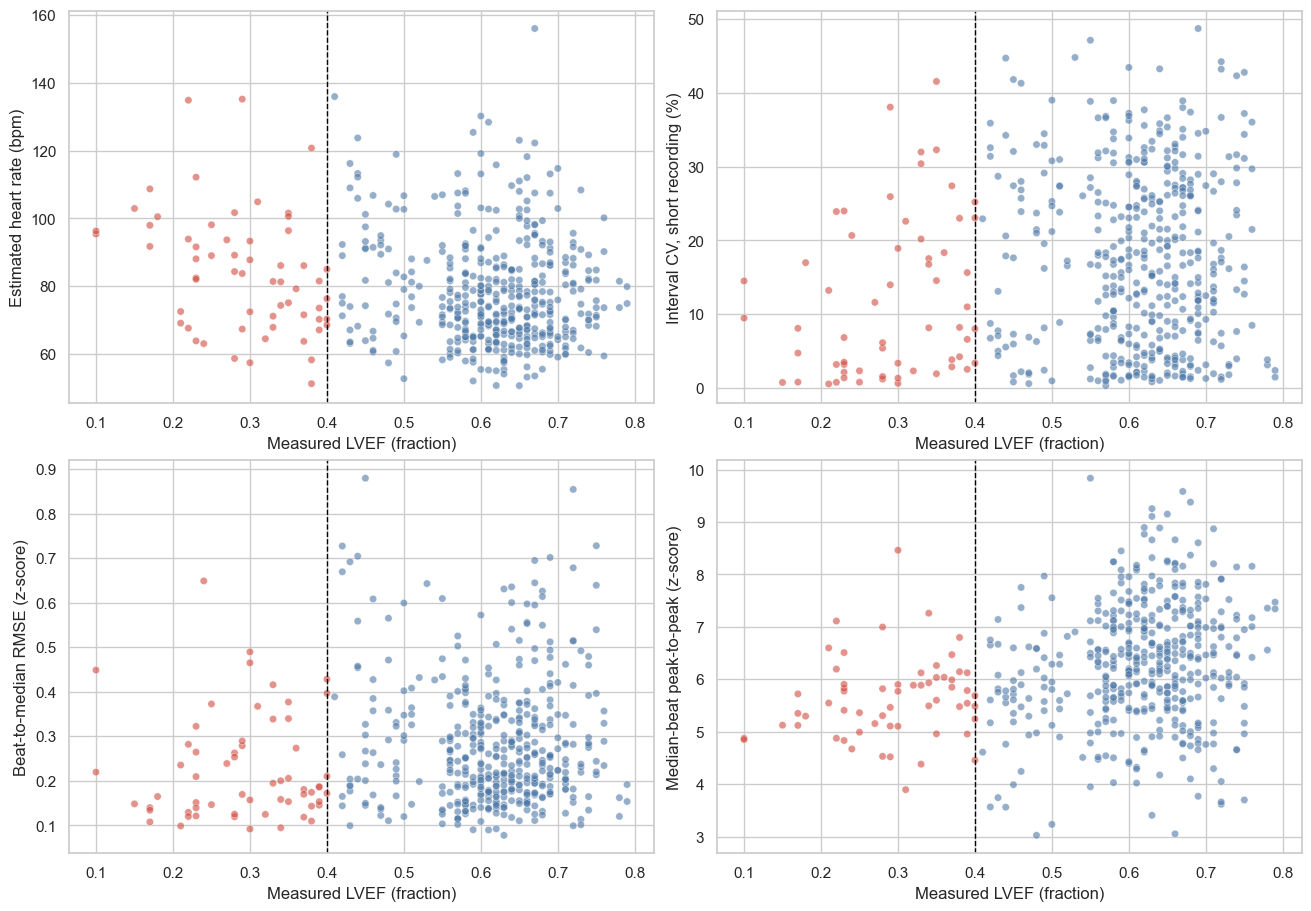

,Site,Label,Patient_site_rows,Unique_patients,estimated_heart_rate_bpm,rr_cv_percent_short_recording,beat_to_median_rmse_z,median_beat_peak_to_peak_z,median_beat_post_pre_rms_ratio,baseline_drift_rms_ratio,high_frequency_rms_ratio
0,APEX,0,440,440,73.037371,9.686996,0.167302,6.608940,1.010157,0.252273,0.014920
1,APEX,1,60,60,83.683473,3.429660,0.144131,5.922906,0.971546,0.174976,0.010320
2,LLSB,0,439,439,73.170732,16.295321,0.249420,6.363918,1.067236,0.273942,0.015489
3,LLSB,1,60,60,85.106554,12.262603,0.192947,5.652048,0.999981,0.241612,0.010407
4,LUSB,0,439,439,75.566751,12.461610,0.178639,6.905705,1.169790,0.289392,0.014343
5,LUSB,1,60,60,84.507042,8.244596,0.174754,5.501456,1.029655,0.236811,0.010465
6,RUSB,0,440,440,78.277920,28.779730,0.409380,5.299812,1.026814,0.461037,0.011893
7,RUSB,1,59,59,82.758621,16.301634,0.373851,5.198877,1.004394,0.461976,0.008153


,Fold,Label,Patients,estimated_heart_rate_bpm,rr_cv_percent_short_recording,beat_to_median_rmse_z,median_beat_peak_to_peak_z,median_beat_post_pre_rms_ratio,baseline_drift_rms_ratio,high_frequency_rms_ratio
0,0,0,88,75.729243,17.628466,0.226652,6.384214,1.056413,0.303940,0.014029
1,0,1,12,86.940525,10.230369,0.158962,5.772232,1.008098,0.217911,0.009672
2,1,0,88,74.196837,16.112499,0.245004,6.350490,1.057509,0.319425,0.014660
3,1,1,12,85.814222,3.344146,0.214520,5.699002,0.975433,0.232660,0.010420
4,2,0,88,73.485351,14.840885,0.223391,6.517735,1.065079,0.283732,0.015176
5,2,1,12,73.804600,10.717712,0.157650,5.892790,1.010875,0.303202,0.010278
6,3,0,88,72.558333,15.058917,0.273585,6.256731,1.076764,0.303177,0.014105
7,3,1,12,87.363552,12.789487,0.216782,5.198547,1.093122,0.296637,0.007847
8,4,0,88,78.364216,20.165312,0.256193,6.143898,1.048611,0.313404,0.014443
9,4,1,12,81.793113,7.426077,0.180683,5.704384,0.982964,0.253645,0.012240


Comparable subset: 396 patients; class counts {0: 345, 1: 51}
Bounds: heart rate 50–120 bpm, baseline ratio <= 0.505, high-frequency ratio <= 0.024, >=3 valid sites.


,Feature,Display_name,HFrEF_median,non_HFrEF_median,Median_difference_HFrEF_minus_non,Bootstrap_95%_low,Bootstrap_95%_high,HFrEF_patients,non_HFrEF_patients
0,estimated_heart_rate_bpm,Estimated heart rate (bpm),84.330,73.710,10.620,5.535,16.596,51,345
1,rr_cv_percent_short_recording,"Interval CV, short recording (%)",6.140,15.196,-9.056,-12.844,-5.252,51,345
2,beat_to_median_rmse_z,Beat-to-median RMSE (z-score),0.169,0.223,-0.053,-0.084,-0.021,51,345
3,median_beat_peak_to_peak_z,Median-beat peak-to-peak (z-score),5.600,6.426,-0.826,-1.098,-0.510,51,345
4,median_beat_post_pre_rms_ratio,Post/pre candidate-peak RMS ratio,1.023,1.068,-0.045,-0.105,0.022,51,345
5,baseline_drift_rms_ratio,Raw baseline RMS / total RMS,0.251,0.291,-0.039,-0.081,-0.010,51,345
6,high_frequency_rms_ratio,Raw >40 Hz RMS / total RMS,0.010,0.014,-0.004,-0.006,-0.003,51,345


,heart_rate_window_span,beat_variability_window_span,valid_windows
Label,,,
0,2.965371,0.094810,3.0
1,1.342688,0.069056,3.0


In [18]:
PLOT_FEATURES = [
    'estimated_heart_rate_bpm', 'rr_cv_percent_short_recording',
    'beat_to_median_rmse_z', 'median_beat_peak_to_peak_z',
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for ax, feature in zip(axes.flat, PLOT_FEATURES):
    sns.boxplot(data=patient_features, x='Label', y=feature, ax=ax, color='#91abc3', showfliers=False)
    sns.stripplot(data=patient_features, x='Label', y=feature, ax=ax, color='#263d52', alpha=.30, size=2.5)
    ax.set(xlabel='Class (0 = non-HFrEF, 1 = HFrEF)', ylabel=FEATURE_LABELS[feature],
           title=f'n={patient_features.groupby("Label")[feature].count().to_dict()}')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for ax, feature in zip(axes.flat, PLOT_FEATURES):
    sns.scatterplot(data=patient_features, x='LVEF', y=feature, hue='Label', ax=ax,
                    palette={0: '#4e79a7', 1: '#d14b40'}, alpha=.6, s=28, legend=False)
    ax.axvline(.40, color='black', linestyle='--', linewidth=1)
    ax.set(xlabel='Measured LVEF (fraction)', ylabel=FEATURE_LABELS[feature])
plt.show()

site_class_summary = (valid_site_features.groupby(['Site', 'Label'])
                      .agg(Patient_site_rows=('Patient_ID', 'size'),
                           Unique_patients=('Patient_ID', 'nunique'),
                           **{feature: (feature, 'median') for feature in FEATURE_LABELS})
                      .reset_index())
fold_class_summary = (patient_features.groupby(['Fold', 'Label'])
                      .agg(Patients=('Patient_ID', 'nunique'),
                           **{feature: (feature, 'median') for feature in FEATURE_LABELS})
                      .reset_index())
display(site_class_summary)
display(fold_class_summary)

# Comparable-range sensitivity analysis with explicit, data-derived quality bounds.
drift_limit = patient_features.baseline_drift_rms_ratio.quantile(.90)
noise_limit = patient_features.high_frequency_rms_ratio.quantile(.90)
comparable = patient_features[
    patient_features.estimated_heart_rate_bpm.between(50, 120) &
    patient_features.baseline_drift_rms_ratio.le(drift_limit) &
    patient_features.high_frequency_rms_ratio.le(noise_limit) &
    patient_features.valid_sites.ge(3)
]
print(f'Comparable subset: {len(comparable)} patients; class counts {comparable.Label.value_counts().sort_index().to_dict()}')
print(f'Bounds: heart rate 50–120 bpm, baseline ratio <= {drift_limit:.3f}, high-frequency ratio <= {noise_limit:.3f}, >=3 valid sites.')
comparable_effect_rows = []
for feature, label in FEATURE_LABELS.items():
    difference, low, high = bootstrap_median_difference(comparable, feature)
    comparable_effect_rows.append({
        'Feature': feature, 'Display_name': label,
        'HFrEF_median': comparable.loc[comparable.Label.eq(1), feature].median(),
        'non_HFrEF_median': comparable.loc[comparable.Label.eq(0), feature].median(),
        'Median_difference_HFrEF_minus_non': difference,
        'Bootstrap_95%_low': low, 'Bootstrap_95%_high': high,
        'HFrEF_patients': comparable.loc[comparable.Label.eq(1), feature].notna().sum(),
        'non_HFrEF_patients': comparable.loc[comparable.Label.eq(0), feature].notna().sum(),
    })
comparable_effect_table = pd.DataFrame(comparable_effect_rows)
display(comparable_effect_table.style.format({
    'HFrEF_median': '{:.3f}', 'non_HFrEF_median': '{:.3f}',
    'Median_difference_HFrEF_minus_non': '{:.3f}',
    'Bootstrap_95%_low': '{:.3f}', 'Bootstrap_95%_high': '{:.3f}',
}))

window_patient = (window_features[window_features.detection_status.eq('ok')]
                  .groupby(['Patient_ID', 'Label', 'LVEF', 'Start_s'], as_index=False)
                  [['estimated_heart_rate_bpm', 'beat_to_median_rmse_z']].median())
window_spans = (window_patient.groupby(['Patient_ID', 'Label'], as_index=False)
                .agg(heart_rate_window_span=('estimated_heart_rate_bpm', lambda x: x.max()-x.min()),
                     beat_variability_window_span=('beat_to_median_rmse_z', lambda x: x.max()-x.min()),
                     valid_windows=('Start_s', 'nunique')))
display(window_spans.groupby('Label')[['heart_rate_window_span', 'beat_variability_window_span', 'valid_windows']].median())

## Same-site ECG–PCG feasibility

The [dataset record](https://zenodo.org/doi/10.5281/zenodo.16934966) describes each ECG/PCG pair as synchronized and says the four auscultation sites were recorded sequentially. Local preprocessing preserves each modality’s full 30-second duration without cropping or resampling. The view below therefore compares timing within one site only. It does not assume alignment between sites and does not label S1, S2, murmurs, or physiological delays.

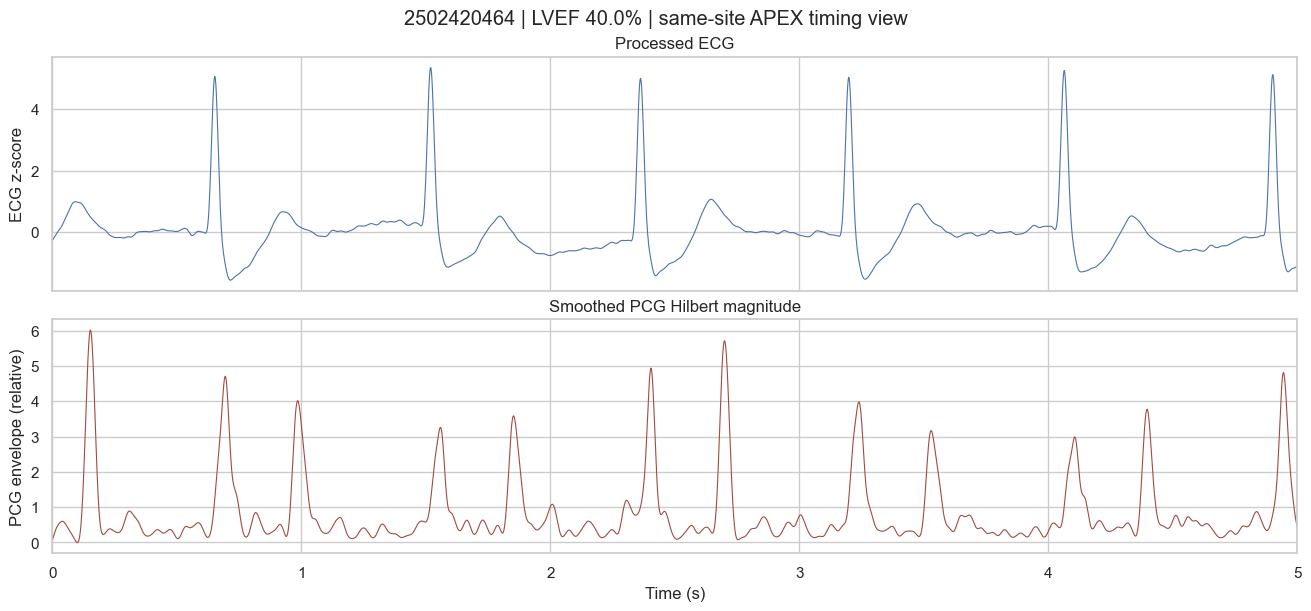

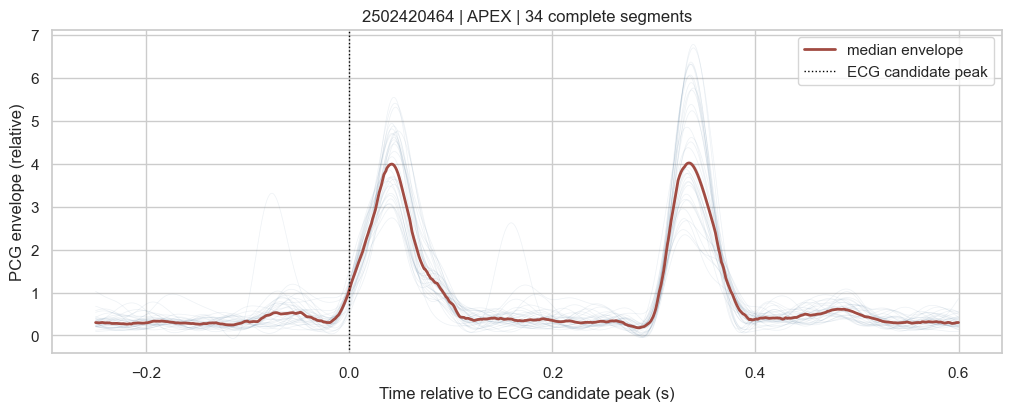

In [19]:
def plot_same_site_ecg_pcg(patient_id, site='APEX', start_s=0.0, duration_s=5.0):
    row = patient_row(patient_id)
    ecg, ecg_fs, _ = load_signal(row.Patient_ID, 'ECG', site, 'processed', row.Split)
    pcg, pcg_fs, _ = load_signal(row.Patient_ID, 'PCG', site, 'processed', row.Split)
    envelope = pcg_envelope(pcg, pcg_fs)
    if start_s < 0 or duration_s <= 0 or start_s + duration_s > DURATION_SECONDS:
        raise ValueError(f'Window must lie within 0–{DURATION_SECONDS} seconds.')
    ecg_left, ecg_right = int(start_s*ecg_fs), int((start_s+duration_s)*ecg_fs)
    pcg_left, pcg_right = int(start_s*pcg_fs), int((start_s+duration_s)*pcg_fs)
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, constrained_layout=True)
    axes[0].plot(np.arange(ecg_left, ecg_right)/ecg_fs, ecg[ecg_left:ecg_right], linewidth=.8)
    axes[0].set(ylabel='ECG z-score', title='Processed ECG')
    axes[1].plot(np.arange(pcg_left, pcg_right)/pcg_fs, envelope[pcg_left:pcg_right], linewidth=.8, color='#a14b42')
    axes[1].set(xlabel='Time (s)', ylabel='PCG envelope (relative)', title='Smoothed PCG Hilbert magnitude')
    axes[1].set_xlim(start_s, start_s+duration_s)
    fig.suptitle(f'{row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | same-site {site} timing view')
    plt.show()
    return fig

def plot_pcg_envelope_at_ecg_candidates(patient_id, site='APEX'):
    row = patient_row(patient_id)
    ecg, ecg_fs, _ = load_signal(row.Patient_ID, 'ECG', site, 'processed', row.Split)
    pcg, pcg_fs, _ = load_signal(row.Patient_ID, 'PCG', site, 'processed', row.Split)
    detection = detect_ecg_beats(ecg, ecg_fs, **DETECTOR_SETTINGS)
    envelope = pcg_envelope(pcg, pcg_fs)
    pre, post = .25, .60
    relative = np.arange(-int(pre*pcg_fs), int(post*pcg_fs)+1) / pcg_fs
    segments = []
    for peak in detection.peaks:
        center = int(round((peak/ecg_fs)*pcg_fs))
        left, right = center-int(pre*pcg_fs), center+int(post*pcg_fs)+1
        if left >= 0 and right <= len(envelope):
            segments.append(envelope[left:right])
    if not segments:
        raise ValueError('No complete ECG-aligned PCG envelope segments.')
    segments = np.asarray(segments)
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    ax.plot(relative, segments.T, alpha=.10, color='#527a9d', linewidth=.5)
    ax.plot(relative, np.median(segments, axis=0), color='#a14b42', linewidth=2, label='median envelope')
    ax.axvline(0, color='black', linestyle=':', linewidth=1, label='ECG candidate peak')
    ax.set(xlabel='Time relative to ECG candidate peak (s)', ylabel='PCG envelope (relative)',
           title=f'{row.Patient_ID} | {site} | {len(segments)} complete segments')
    ax.legend()
    plt.show()
    return fig

PCG_FEASIBILITY_PATIENT = comparison_groups['near_cutoff_hfref'].iloc[0].Patient_ID
_ = plot_same_site_ecg_pcg(PCG_FEASIBILITY_PATIENT, site='APEX')
_ = plot_pcg_envelope_at_ecg_candidates(PCG_FEASIBILITY_PATIENT, site='APEX')

## Evidence for future experiments

This table records only findings calculated above. These are exploratory associations in the development cohort. They do not establish causality, clinical validity, or what the trained neural network uses.

In [20]:
def effect_sentence(feature):
    row = effect_table.loc[effect_table.Feature.eq(feature)].iloc[0]
    return (f'HFrEF median {row.HFrEF_median:.2f}; non-HFrEF median {row.non_HFrEF_median:.2f}; '
            f'median difference {row.Median_difference_HFrEF_minus_non:.2f} '
            f'(patient-bootstrap 95% interval {row["Bootstrap_95%_low"]:.2f} to {row["Bootstrap_95%_high"]:.2f}); '
            f'n={int(row.HFrEF_patients)} and {int(row.non_HFrEF_patients)} patients.')

def comparable_effect_sentence(feature):
    row = comparable_effect_table.loc[comparable_effect_table.Feature.eq(feature)].iloc[0]
    return (f'Comparable-range subset: HFrEF median {row.HFrEF_median:.2f}; '
            f'non-HFrEF median {row.non_HFrEF_median:.2f}; median difference '
            f'{row.Median_difference_HFrEF_minus_non:.2f} '
            f'(patient-bootstrap 95% interval {row["Bootstrap_95%_low"]:.2f} to '
            f'{row["Bootstrap_95%_high"]:.2f}); n={int(row.HFrEF_patients)} and '
            f'{int(row.non_HFrEF_patients)} patients.')

evidence_table = pd.DataFrame([
    {
        'Observation': 'Candidate-beat rate differs descriptively between classes.',
        'Evidence and patient count': effect_sentence('estimated_heart_rate_bpm'),
        'Alternative explanation': 'Age, medication, rhythm, acquisition context, or detector behavior may confound the association.',
        'Possible follow-up experiment': 'Stratify validation analysis by heart-rate range while preserving patient-level splits.',
    },
    {
        'Observation': 'Relative median-beat peak-to-peak morphology differs descriptively.',
        'Evidence and patient count': effect_sentence('median_beat_peak_to_peak_z'),
        'Alternative explanation': 'Per-recording z-scoring, site geometry, polarity, and recording quality affect this relative measure.',
        'Possible follow-up experiment': 'Test whether morphology-preserving crops retain performance; avoid amplitude deformation until validated.',
    },
    {
        'Observation': 'The peak-to-peak difference remains in the prespecified comparable-range sensitivity subset.',
        'Evidence and patient count': comparable_effect_sentence('median_beat_peak_to_peak_z'),
        'Alternative explanation': 'The subset still has strong class imbalance and does not match age, medication, diagnosis, or acquisition conditions.',
        'Possible follow-up experiment': 'Repeat the summary inside validation folds and heart-rate strata before selecting an augmentation.',
    },
    {
        'Observation': 'Raw recording-quality proxies also differ between classes.',
        'Evidence and patient count': (effect_sentence('baseline_drift_rms_ratio') + ' ' +
                                       effect_sentence('high_frequency_rms_ratio')),
        'Alternative explanation': 'Acquisition equipment, contact, site placement, or cohort collection may explain part of the apparent waveform separation.',
        'Possible follow-up experiment': 'Audit acquisition-quality balance by fold; test mild noise only if it reproduces observed development noise without changing morphology.',
    },
    {
        'Observation': 'The post/pre candidate-peak RMS ratio is inconclusive.',
        'Evidence and patient count': effect_sentence('median_beat_post_pre_rms_ratio'),
        'Alternative explanation': 'The fixed window and per-recording z-score representation may obscure or create relative differences.',
        'Possible follow-up experiment': 'Do not prioritize this descriptor unless it becomes stable across sites and independently reviewed windows.',
    },
    {
        'Observation': 'Automated candidate detection succeeds on nearly all patient-site recordings.',
        'Evidence and patient count': f'{site_features.detection_status.eq("ok").sum()}/{len(site_features)} site recordings; all {site_features.Patient_ID.nunique()} development patients retained.',
        'Alternative explanation': 'Passing interval checks does not prove every marker is a true R wave.',
        'Possible follow-up experiment': 'Manually audit a stratified set of overlays, including every flagged recording.',
    },
    {
        'Observation': 'Feature estimates vary across 5-second windows within patients.',
        'Evidence and patient count': (f'Median heart-rate span {window_spans.heart_rate_window_span.median():.2f} bpm and '
                                       f'beat-variability span {window_spans.beat_variability_window_span.median():.3f} z-score units '
                                       f'across {len(window_spans)} development patients.'),
        'Alternative explanation': 'Short windows contain fewer beats and amplify detector and sampling variability.',
        'Possible follow-up experiment': 'Evaluate random cropping while monitoring whether estimates and validation performance remain stable.',
    },
    {
        'Observation': 'Same-site ECG-aligned PCG structure is feasible to visualize but remains inconclusive.',
        'Evidence and patient count': 'Descriptive envelope plots were generated for one development patient; no cohort PCG event detector was validated.',
        'Alternative explanation': 'Envelope structure can reflect noise, filtering, or imperfect alignment.',
        'Possible follow-up experiment': 'Audit synchronization and envelope repeatability in a prespecified development subset before PCG augmentation.',
    },
])
display(evidence_table)

,Observation,Evidence and patient count,Alternative explanation,Possible follow-up experiment
0,Candidate-beat rate differs descriptively betw...,HFrEF median 83.11; non-HFrEF median 74.35; me...,"Age, medication, rhythm, acquisition context, ...",Stratify validation analysis by heart-rate ran...
1,Relative median-beat peak-to-peak morphology d...,HFrEF median 5.57; non-HFrEF median 6.35; medi...,"Per-recording z-scoring, site geometry, polari...",Test whether morphology-preserving crops retai...
2,The peak-to-peak difference remains in the pre...,Comparable-range subset: HFrEF median 5.60; no...,The subset still has strong class imbalance an...,Repeat the summary inside validation folds and...
3,Raw recording-quality proxies also differ betw...,HFrEF median 0.25; non-HFrEF median 0.31; medi...,"Acquisition equipment, contact, site placement...",Audit acquisition-quality balance by fold; tes...
4,The post/pre candidate-peak RMS ratio is incon...,HFrEF median 1.00; non-HFrEF median 1.06; medi...,The fixed window and per-recording z-score rep...,Do not prioritize this descriptor unless it be...
5,Automated candidate detection succeeds on near...,1997/2000 site recordings; all 500 development...,Passing interval checks does not prove every m...,"Manually audit a stratified set of overlays, i..."
6,Feature estimates vary across 5-second windows...,Median heart-rate span 2.67 bpm and beat-varia...,Short windows contain fewer beats and amplify ...,Evaluate random cropping while monitoring whet...
7,Same-site ECG-aligned PCG structure is feasibl...,Descriptive envelope plots were generated for ...,"Envelope structure can reflect noise, filterin...",Audit synchronization and envelope repeatabili...


## Draft notes — context and proposed next steps

**Status: provisional notes from the read-only review on 11 September 2026. These are not completed experiments or approved changes.** Sources: this notebook, the two development feature CSVs in `analysis_outputs`, `src/signal_analysis.py`, preprocessing/training/model code, notebooks 2–3, and saved ECG fold-0 artifacts. No test results were used to choose the recommendations.

### Additional evidence and limits

- **Baseline verification:** replay on the 100 development validation patients reproduced AUROC 0.95644 and average precision 0.76861. Brier score was 0.06274 versus 0.10560 for a constant 12% prediction; this does not establish calibration.
- **Threshold sensitivity:** the notebook reported 11/12 HFrEF cases detected; CPU replay gave 10/12. Patient `2502459743` scored about 0.00000018 below the saved threshold (0.511748731). This numerical boundary changes sensitivity by 8.3 percentage points without changing ranking performance. For future experiments, choose a threshold between adjacent tuning scores where possible and document the rule; preserve the current checkpoint.
- **Split and duplication checks:** every development fold has 12 HFrEF and 88 non-HFrEF patients. Saved training/validation IDs match the intended folds without overlap. Metadata and feature-table keys agree. No exact duplicate development ECG patient tensors or site arrays were found. Near-duplicates, PCG waveform duplication, and repeated people under different IDs were not ruled out.
- **Residual heart-rate differences:** the restricted subset contains 396 patients (51 HFrEF, 345 non-HFrEF), with median rates still 84.3 versus 73.7 bpm. It is not a matched comparison. Standardized peak-to-peak values correlate with heart rate within each class (Spearman approximately -0.59 in HFrEF and -0.34 in non-HFrEF). Their class difference cannot yet be separated from heart rate or normalization.
- **Site/fold variation:** the class difference in estimated heart rate is almost absent in fold 2. RUSB has higher baseline-drift and interval-variability summaries than APEX. Acquisition, physiology, and detector behavior are possible explanations.
- **Quality is only a proxy:** raw content below 0.5 Hz and above 40 Hz is measured before the model's filtering. Class differences do not prove that the model uses those frequencies. Full-scale samples and constant runs need visual confirmation. Age, medication, and other clinical variables are unavailable in the processed metadata.
- **Window/PCG limits:** median estimated-rate span across the three five-second windows is 2.67 bpm; this does not establish equivalent predictive information in every crop. One ECG-aligned PCG example shows repeating structure, but no cohort PCG event detector or class difference has been validated.
- **Existing experiments:** ECG already uses focal loss with alpha 0.88 and gamma 2.0; the generic training helper defaults to weighted BCE if no criterion is supplied. PCG code already includes random 15-second crops, but no saved local PCG run verifies their benefit. A separate five-second ECG history lacks sufficient accompanying provenance for a fair baseline comparison.

### Analysis issues to correct before experiments

- Audit candidate peaks in a seeded sample spanning both classes, folds, sites, and quality levels, including flagged recordings. Of full-recording rows marked `ok`, 16 still contain rejected intervals, which are omitted from timing summaries. The 6,000 window rows include 17 flagged detections. Report rejected intervals, insufficient usable beats, and missing measurements explicitly; retain all patients.
- Keep raw-quality summaries available when beat detection fails. Current patient aggregation excludes failed site rows, including their quality measurements.
- Record detector/window settings and source versions with cached tables and validate them on loading. Actual default beat windows are -0.20 to +0.28 seconds; update notes when settings change.
- Include the interquartile envelopes in median-comparison axis limits so uncertainty bands cannot be clipped.
- Bind blinded observations to the last loaded recording and clear/reload fields appropriately. Changing controls before saving can currently attach a note to the wrong view.
- The ECG stem immediately combines sites recorded at different times. Investigate sensitivity to incidental relative timing before considering architecture changes. The [dataset paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC13100685/) confirms synchronization within ECG/PCG pairs and sequential acquisition across sites.

### Proposed first experiment: development baseline and shortcut audit

Compare the unchanged ECG architecture/loss with three fixed, simple regularized logistic-regression baselines: heart rate only, recording quality only, and both. Retain site-specific quality information, exclude IDs/filenames/LVEF/fold as predictors, and handle failed measurements explicitly. Strong quality-only performance would raise concern; weak performance would not rule out complex shortcuts. Heart rate can carry legitimate predictive information.

For scoring fold k, use fold (k+1) modulo 5 for tuning and the remaining three folds for training: 300 training, 100 tuning, and 100 scoring patients. Repeat across all five scoring folds. Use tuning patients for early stopping, learning-rate scheduling, and threshold selection. Fit scaling, imputation, quality boundaries, and any calibration without scoring-fold data. Every model must use this same protocol; it has fewer training patients than the historical 400-patient baseline.

Report average precision as primary (development prevalence reference 0.12), AUROC, sensitivity, specificity, balanced accuracy, precision, F1, confusion counts, Brier score, log loss, and a reliability plot. Initially use maximum tuning-fold F1 as the threshold-selection rule. Report every fold and one prediction per scored patient, with paired bootstrap intervals stratified by fold and class. Beats/sites/windows are not independent patients; these intervals do not capture all training randomness. Report subgroup denominators and undefined metrics. The current fold's highest raw high-frequency-measure group contains no HFrEF patients, so its sensitivity cannot be evaluated.

### Conditional follow-ups, not a large search

- **Cropping:** after the audit, compare full 30-second training, fixed central 15-second training, and random 15-second training. The fixed crop separates shorter input from randomness. Keep loss, patient sampling, training limits, normalization, and full 30-second evaluation consistent.
- **Noise:** test one mild condition only if its type and strength are justified from training recordings and its effect is relevant after preprocessing. Apply it equally across classes. Improvement only on artificial corruptions is not evidence of improvement on original recordings.
- **Avoid for now:** strong amplitude changes, time stretching/warping, arbitrary site permutations, and extra class balancing stacked on the weighted loss. Weighting changes class importance; augmentation changes views of recordings. Neither creates independent patients.
- **Draft decision targets:** mean fold AUPRC gain of at least 0.03, gains in at least four of five folds, no overall sensitivity decrease above 5 percentage points or specificity decrease above 2 points, and a paired improvement interval excluding zero before claiming benefit. These are research targets, not clinical requirements. Confirm a promising comparison with one additional paired seed; otherwise retain the baseline and describe uncertainty as inconclusive.
- Keep test data out of selection, tuning, early stopping, and visual hypothesis generation. Historical test evaluation already exists; further development does not restore an untouched test set. Previously explored development results remain exploratory. [Model-selection bias reference](https://jmlr.org/papers/v11/cawley10a.html)

**Working decision:** investigate reliability and possible shortcuts first; preserve the current model while deciding whether augmentation is warranted.

## Visual-review checklist and notes

Use repeated observations across patients and sites to form testable hypotheses. Avoid interpreting a trace as a diagnosis or as proof of what the model learned.

- Rhythm regularity and repeating intervals within one recording
- Recurring morphology differences visible across several patients
- Baseline drift, high-frequency noise, clipping, or dropouts
- Differences between acquisition sites, without assuming simultaneous timing
- Whether a suspected pattern remains visible near the 40% boundary and in randomly selected controls
- Whether an apparent group difference could instead reflect recording quality or preprocessing

The empty table below is a structured place for observations. Add rows manually.

In [21]:
observation_notes = pd.DataFrame([{'Patient_ID': '1008663920'}], columns=[
    'Patient_ID', 'Site', 'Time_interval_s', 'Observation',
    'Possible_artifact', 'Hypothesis_to_investigate',
]).fillna('')

display(observation_notes)

,Patient_ID,Site,Time_interval_s,Observation,Possible_artifact,Hypothesis_to_investigate
0,1008663920,,,,,
